<a href="https://colab.research.google.com/github/Dalbeth/Data-Science-Cohort-20/blob/main/Project_2/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Housing Price Prediction


## Problem Definition

The goal is to take housing data, including price and features and develop a model that can predict price from the features of a house. This prediction will be done using Regression prediction techniques
The performance goal of the predictive model is to minimize the RMS ***percentage*** error ( root mean squared percentage error - RMSPE ) on the prediction of the house sales price.



## Data Collection & Source


### Data Overview

A data dictionary file is available at AWS S3 at [Housing Data Dictionary]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf ).

The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv

### Tool imports

Tools necessary for data visualization, analysis and testing are loaded

In [341]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.style.use('ggplot')

### Data Loading

Next, data is loaded from the url and used to create a dataframe. The creation of the dataframe is then confirmed.

In [342]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [343]:
housing_df = pd.read_csv( url )
housing_df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


### Summarizing the information

Next a quick summary of the data is done

In [344]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

The data is a dataframe with 81 columns and 2637 rows.  This quick summary shows the presence of null values which will need to be addressed in data cleaning. Additionally, there are object, integers and float data types present.

### Describing the Data

Next, quick views are used to gain an understanding of the data to create a plan for data cleaning.

In [345]:
housing_df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [346]:
housing_df.tail()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000
2636,528292060,60,RL,41.0,12460,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,225000


Examining the head shows that the column names look right and that the top row does not appear to be carry over from column names.

Looking at the tail shows that the final rows dont appear to be summed data.

## Data Cleaning

The data was further explored to develop a plan to clean the data and the data was cleaned to create a usable data set.  



### Creating a backup

Before any data cleaning is done, a backup of the data is created to keep a clean copy of the data available

In [347]:
housing_df_bak01 = housing_df.copy()
housing_df_bak01

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [348]:
housing_df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


### Exploring the target data

Next, the house pricing data is explored to ensure there are no null values in the target.

In [349]:
housing_df["SalePrice"].value_counts( dropna= False)

,count
SalePrice,
140000,31
135000,30
130000,28
155000,24
160000,22
...,...
160200,1
174190,1
415298,1


In [350]:
housing_df["SalePrice"].isnull().sum()

np.int64(0)

There are no null values in the house sales price data, so no rows will be dropped as part of the data cleaning process.

### Exploring & cleaning the data columns

Now that it has been confirmed no rows need to be dropped due to nulls within the sales price target data, the feature columns were explored to generate a plan for cleaning the features.

In [351]:
housing_df.isna().sum().sort_values(ascending=False)*100/len(housing_df)

,0
Pool QC,99.582859
Misc Feature,96.359499
Alley,93.174061
Fence,79.977247
Mas Vnr Type,60.940463
...,...
Mo Sold,0.000000
Yr Sold,0.000000
Sale Type,0.000000
Sale Condition,0.000000


Some of the columns contain primarily null data, which cannot be predicted upon.  For this analysis, columns will only be kept if 100% of the data is present.

In [352]:
threshold = int(1.0 * len(housing_df))
housing_dfcleaned = housing_df.dropna(axis=1, thresh=threshold)
housing_dfcleaned

,PID,MS SubClass,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,14299,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2007,WD,Normal,115400
1,905101330,90,RL,10791,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,500,10,2006,WD,Normal,90000
2,903454090,50,RM,9000,Pave,Reg,Bnk,AllPub,Inside,Gtl,...,0,0,126,0,0,12,2007,WD,Normal,141000
3,533244030,60,FV,7379,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,254000
4,909252020,70,RL,7200,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,6240,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,10778,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,3782,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,0,0,0,0,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,10140,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2009,WD,Normal,165000


In [353]:
housing_dfcleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 55 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   PID              2637 non-null   int64 
 1   MS SubClass      2637 non-null   int64 
 2   MS Zoning        2637 non-null   object
 3   Lot Area         2637 non-null   int64 
 4   Street           2637 non-null   object
 5   Lot Shape        2637 non-null   object
 6   Land Contour     2637 non-null   object
 7   Utilities        2637 non-null   object
 8   Lot Config       2637 non-null   object
 9   Land Slope       2637 non-null   object
 10  Neighborhood     2637 non-null   object
 11  Condition 1      2637 non-null   object
 12  Condition 2      2637 non-null   object
 13  Bldg Type        2637 non-null   object
 14  House Style      2637 non-null   object
 15  Overall Qual     2637 non-null   int64 
 16  Overall Cond     2637 non-null   int64 
 17  Year Built       2637 non-null   

Dropping all columns that were not 100% complete removed: Lot Frontage, Alley, Masonry Venear columns, all basement associated columns, all garage associated columns, pool quality, fence type and miscelaneous features.  

This could be problematic as basement or garage features might be important for price prediction but will be left dropped for this data analysis iteration.

As linear regression requires integers or float data types, the object data type columns must either be converted or dropped. To simplify the analysis in this current iteration, a few of the object columns will be converted to integers and the remaining columns containing object data will be dropped.

PID is a unique identifier so it will  be removed.  

In [354]:
housing_dfcleaned = housing_dfcleaned.drop(columns=['PID'])
housing_dfcleaned.head()

,MS SubClass,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,14299,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,...,0,0,0,0,0,7,2007,WD,Normal,115400
1,90,RL,10791,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,...,0,0,0,0,500,10,2006,WD,Normal,90000
2,50,RM,9000,Pave,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,...,0,0,126,0,0,12,2007,WD,Normal,141000
3,60,FV,7379,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,...,0,0,0,0,0,4,2010,WD,Normal,254000
4,70,RL,7200,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,...,0,0,0,0,0,4,2009,WD,Normal,155000


In [355]:
housing_dfcleaned.dtypes.value_counts()

,count
object,28
int64,26


MS Subclass is encoded as an integer, but review of the data dictionary shows that the order does not make sense, this could be re-encoded, but for this run it will be dropped.

In [356]:
housing_dfcleaned = housing_dfcleaned.drop(columns=['MS SubClass'])
housing_dfcleaned.head()

,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,RL,14299,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,...,0,0,0,0,0,7,2007,WD,Normal,115400
1,RL,10791,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,...,0,0,0,0,500,10,2006,WD,Normal,90000
2,RM,9000,Pave,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,...,0,0,126,0,0,12,2007,WD,Normal,141000
3,FV,7379,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,...,0,0,0,0,0,4,2010,WD,Normal,254000
4,RL,7200,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,...,0,0,0,0,0,4,2009,WD,Normal,155000


For this pass, a selected set of columns will be further explored and potentially encoded, these were selected as being the most likely to affect the outcome. The selected columns are: Utilities, Neighborhood, Building Type, heating, heating quality, central air, ktichen quality and sales condition.

In [357]:
housing_dfcleaned['Utilities'].value_counts()

,count
Utilities,
AllPub,2634
NoSewr,2
NoSeWa,1


Based on these results, that nearly all properties have public utilities, this column will be dropped.

In [358]:
housing_dfcleaned = housing_dfcleaned.drop(columns=['Utilities'])
housing_dfcleaned.head()

,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,RL,14299,Pave,Reg,Lvl,Inside,Gtl,Sawyer,Feedr,Norm,...,0,0,0,0,0,7,2007,WD,Normal,115400
1,RL,10791,Pave,Reg,Lvl,Inside,Gtl,Sawyer,Norm,Norm,...,0,0,0,0,500,10,2006,WD,Normal,90000
2,RM,9000,Pave,Reg,Bnk,Inside,Gtl,IDOTRR,Norm,Norm,...,0,0,126,0,0,12,2007,WD,Normal,141000
3,FV,7379,Pave,IR1,Lvl,Inside,Gtl,Somerst,Norm,Norm,...,0,0,0,0,0,4,2010,WD,Normal,254000
4,RL,7200,Pave,Reg,Lvl,Inside,Gtl,SWISU,Feedr,Norm,...,0,0,0,0,0,4,2009,WD,Normal,155000


In [359]:
housing_dfcleaned['Neighborhood'].value_counts()

,count
Neighborhood,
NAmes,397
CollgCr,240
OldTown,218
Edwards,168
Somerst,161
NridgHt,150
Gilbert,149
Sawyer,138
NWAmes,116


Neighborhoods were varied and location can be important for sales price, so this was encoded.

In [360]:
housing_dfcleaned = pd.get_dummies(housing_dfcleaned, columns=["Neighborhood"], prefix="", prefix_sep="", dtype='int')
housing_dfcleaned

,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Lot Config,Land Slope,Condition 1,Condition 2,Bldg Type,...,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker
0,RL,14299,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,1Fam,...,0,0,0,0,1,0,0,0,0,0
1,RL,10791,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,Duplex,...,0,0,0,0,1,0,0,0,0,0
2,RM,9000,Pave,Reg,Bnk,Inside,Gtl,Norm,Norm,1Fam,...,0,0,0,0,0,0,0,0,0,0
3,FV,7379,Pave,IR1,Lvl,Inside,Gtl,Norm,Norm,1Fam,...,0,0,0,0,0,0,1,0,0,0
4,RL,7200,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,1Fam,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,6240,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Fam,...,0,0,0,0,0,0,0,0,0,0
2633,RL,10778,Pave,IR1,Lvl,Inside,Gtl,Feedr,Norm,1Fam,...,0,0,0,0,0,1,0,0,0,0
2634,RL,3782,Pave,IR1,Lvl,CulDSac,Gtl,Norm,Norm,TwnhsE,...,0,0,0,0,0,0,0,0,0,0
2635,RL,10140,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Fam,...,0,0,0,0,0,0,0,0,0,0


In [361]:
housing_dfcleaned['Bldg Type'].value_counts()

,count
Bldg Type,
1Fam,2187
TwnhsE,210
Duplex,95
Twnhs,90
2fmCon,55


Building type showed variable types which could affect price so this data will be encoded.

In [362]:
housing_dfcleaned = pd.get_dummies(housing_dfcleaned, columns=["Bldg Type"], prefix="", prefix_sep="", dtype='int')
housing_dfcleaned

,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Lot Config,Land Slope,Condition 1,Condition 2,House Style,...,SawyerW,Somerst,StoneBr,Timber,Veenker,1Fam,2fmCon,Duplex,Twnhs,TwnhsE
0,RL,14299,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,1Story,...,0,0,0,0,0,1,0,0,0,0
1,RL,10791,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,0,0,0,0,0,0,0,1,0,0
2,RM,9000,Pave,Reg,Bnk,Inside,Gtl,Norm,Norm,1.5Fin,...,0,0,0,0,0,1,0,0,0,0
3,FV,7379,Pave,IR1,Lvl,Inside,Gtl,Norm,Norm,2Story,...,0,1,0,0,0,1,0,0,0,0
4,RL,7200,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,2Story,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,6240,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1.5Fin,...,0,0,0,0,0,1,0,0,0,0
2633,RL,10778,Pave,IR1,Lvl,Inside,Gtl,Feedr,Norm,SLvl,...,1,0,0,0,0,1,0,0,0,0
2634,RL,3782,Pave,IR1,Lvl,CulDSac,Gtl,Norm,Norm,1Story,...,0,0,0,0,0,0,0,0,0,1
2635,RL,10140,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,0,0,0,0,0,1,0,0,0,0


In [363]:
housing_dfcleaned['Heating'].value_counts()

,count
Heating,
GasA,2597
GasW,23
Grav,9
Wall,5
OthW,2
Floor,1


As most of the heating types were the same, this column was dropped

In [364]:
housing_dfcleaned = housing_dfcleaned.drop(columns=['Heating'])

In [365]:
housing_dfcleaned['Heating QC'].value_counts()

,count
Heating QC,
Ex,1355
TA,778
Gd,419
Fa,82
Po,3


Heating quality varied and as this can be an expensive item to address, the quality of the system may affect price.  This feature was encoded.

In [366]:
housing_dfcleaned = pd.get_dummies(housing_dfcleaned, columns=["Heating QC"], prefix="Heat QC", prefix_sep=" ", dtype='int')
housing_dfcleaned

,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Lot Config,Land Slope,Condition 1,Condition 2,House Style,...,1Fam,2fmCon,Duplex,Twnhs,TwnhsE,Heat QC Ex,Heat QC Fa,Heat QC Gd,Heat QC Po,Heat QC TA
0,RL,14299,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,1Story,...,1,0,0,0,0,0,0,0,0,1
1,RL,10791,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,0,0,1,0,0,0,0,0,0,1
2,RM,9000,Pave,Reg,Bnk,Inside,Gtl,Norm,Norm,1.5Fin,...,1,0,0,0,0,0,0,0,0,1
3,FV,7379,Pave,IR1,Lvl,Inside,Gtl,Norm,Norm,2Story,...,1,0,0,0,0,1,0,0,0,0
4,RL,7200,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,2Story,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,6240,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1.5Fin,...,1,0,0,0,0,0,0,0,0,1
2633,RL,10778,Pave,IR1,Lvl,Inside,Gtl,Feedr,Norm,SLvl,...,1,0,0,0,0,0,0,1,0,0
2634,RL,3782,Pave,IR1,Lvl,CulDSac,Gtl,Norm,Norm,1Story,...,0,0,0,0,1,0,0,0,0,1
2635,RL,10140,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,1,0,0,0,0,0,0,0,0,1


In [367]:
housing_dfcleaned['Central Air'].value_counts()

,count
Central Air,
Y,2460
N,177


As central air can be an important feature, this will be encoded.  As there are only 2 variables, the values will be replaced with 1 for yes and 0 for no.

In [368]:
housing_dfcleaned['Central Air'] = housing_dfcleaned['Central Air'].replace({'Y': "1", 'N': "0"}).astype(int)

In [369]:
housing_dfcleaned['Central Air'].value_counts()

,count
Central Air,
1,2460
0,177


In [370]:
housing_dfcleaned['Kitchen Qual'].value_counts()

,count
Kitchen Qual,
TA,1342
Gd,1052
Ex,184
Fa,59


Kitchen quality can be an important feature so this will be encoded.

In [371]:
housing_dfcleaned = pd.get_dummies(housing_dfcleaned, columns=["Kitchen Qual"], prefix="Kitchen", prefix_sep=" ", dtype='int')
housing_dfcleaned

,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Lot Config,Land Slope,Condition 1,Condition 2,House Style,...,TwnhsE,Heat QC Ex,Heat QC Fa,Heat QC Gd,Heat QC Po,Heat QC TA,Kitchen Ex,Kitchen Fa,Kitchen Gd,Kitchen TA
0,RL,14299,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,1Story,...,0,0,0,0,0,1,0,0,0,1
1,RL,10791,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,0,0,0,0,0,1,0,0,0,1
2,RM,9000,Pave,Reg,Bnk,Inside,Gtl,Norm,Norm,1.5Fin,...,0,0,0,0,0,1,0,0,1,0
3,FV,7379,Pave,IR1,Lvl,Inside,Gtl,Norm,Norm,2Story,...,0,1,0,0,0,0,0,0,1,0
4,RL,7200,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,2Story,...,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,6240,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1.5Fin,...,0,0,0,0,0,1,0,0,0,1
2633,RL,10778,Pave,IR1,Lvl,Inside,Gtl,Feedr,Norm,SLvl,...,0,0,0,1,0,0,0,0,1,0
2634,RL,3782,Pave,IR1,Lvl,CulDSac,Gtl,Norm,Norm,1Story,...,1,0,0,0,0,1,0,0,1,0
2635,RL,10140,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,0,0,0,0,0,1,0,0,0,1


In [372]:
housing_dfcleaned['Sale Condition'].value_counts()

,count
Sale Condition,
Normal,2166
Partial,222
Abnorml,174
Family,44
Alloca,21
AdjLand,10


Sales condition unusual sales conditions such as within family, which could significantly alter sales price, so this will be encoded.

In [373]:
housing_dfcleaned = pd.get_dummies(housing_dfcleaned, columns=["Sale Condition"], prefix="", prefix_sep="", dtype='int')
housing_dfcleaned

,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Lot Config,Land Slope,Condition 1,Condition 2,House Style,...,Kitchen Ex,Kitchen Fa,Kitchen Gd,Kitchen TA,Abnorml,AdjLand,Alloca,Family,Normal,Partial
0,RL,14299,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,1Story,...,0,0,0,1,0,0,0,0,1,0
1,RL,10791,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,0,0,0,1,0,0,0,0,1,0
2,RM,9000,Pave,Reg,Bnk,Inside,Gtl,Norm,Norm,1.5Fin,...,0,0,1,0,0,0,0,0,1,0
3,FV,7379,Pave,IR1,Lvl,Inside,Gtl,Norm,Norm,2Story,...,0,0,1,0,0,0,0,0,1,0
4,RL,7200,Pave,Reg,Lvl,Inside,Gtl,Feedr,Norm,2Story,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,6240,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1.5Fin,...,0,0,0,1,0,0,0,0,1,0
2633,RL,10778,Pave,IR1,Lvl,Inside,Gtl,Feedr,Norm,SLvl,...,0,0,1,0,0,0,0,0,1,0
2634,RL,3782,Pave,IR1,Lvl,CulDSac,Gtl,Norm,Norm,1Story,...,0,0,1,0,0,0,0,0,1,0
2635,RL,10140,Pave,Reg,Lvl,Inside,Gtl,Norm,Norm,1Story,...,0,0,0,1,0,0,0,0,1,0


Finally the remaining object columns were dropped.

In [374]:
housing_dfcleaned = housing_dfcleaned.select_dtypes(exclude=['object'])
housing_dfcleaned

,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Central Air,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Kitchen Ex,Kitchen Fa,Kitchen Gd,Kitchen TA,Abnorml,AdjLand,Alloca,Family,Normal,Partial
0,14299,4,3,1964,1964,1,1005,0,0,1005,...,0,0,0,1,0,0,0,0,1,0
1,10791,4,5,1967,1967,1,1296,0,0,1296,...,0,0,0,1,0,0,0,0,1,0
2,9000,6,6,1937,1950,1,780,595,0,1375,...,0,0,1,0,0,0,0,0,1,0
3,7379,8,5,2000,2000,1,975,873,0,1848,...,0,0,1,0,0,0,0,0,1,0
4,7200,7,9,1936,2007,1,575,560,0,1135,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,6240,6,6,1934,1950,1,816,0,360,1176,...,0,0,0,1,0,0,0,0,1,0
2633,10778,7,6,1990,1991,1,1061,0,0,1061,...,0,0,1,0,0,0,0,0,1,0
2634,3782,8,5,1981,1981,1,1226,0,0,1226,...,0,0,1,0,0,0,0,0,1,0
2635,10140,6,5,1974,1974,1,1350,0,0,1350,...,0,0,0,1,0,0,0,0,1,0


In [375]:
housing_dfcleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 74 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Lot Area         2637 non-null   int64
 1   Overall Qual     2637 non-null   int64
 2   Overall Cond     2637 non-null   int64
 3   Year Built       2637 non-null   int64
 4   Year Remod/Add   2637 non-null   int64
 5   Central Air      2637 non-null   int64
 6   1st Flr SF       2637 non-null   int64
 7   2nd Flr SF       2637 non-null   int64
 8   Low Qual Fin SF  2637 non-null   int64
 9   Gr Liv Area      2637 non-null   int64
 10  Full Bath        2637 non-null   int64
 11  Half Bath        2637 non-null   int64
 12  Bedroom AbvGr    2637 non-null   int64
 13  Kitchen AbvGr    2637 non-null   int64
 14  TotRms AbvGrd    2637 non-null   int64
 15  Fireplaces       2637 non-null   int64
 16  Wood Deck SF     2637 non-null   int64
 17  Open Porch SF    2637 non-null   int64
 18  Enclosed

### Reordering the sales column

The dataframe is very large, to faciliate visualizing the correlations, I moved the target 'SalePrice' column to the first column in the dataframe.

In [376]:
col = housing_dfcleaned.pop('SalePrice')
housing_dfcleaned.insert(0, 'SalePrice', col)

In [377]:
housing_dfcleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 74 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   SalePrice        2637 non-null   int64
 1   Lot Area         2637 non-null   int64
 2   Overall Qual     2637 non-null   int64
 3   Overall Cond     2637 non-null   int64
 4   Year Built       2637 non-null   int64
 5   Year Remod/Add   2637 non-null   int64
 6   Central Air      2637 non-null   int64
 7   1st Flr SF       2637 non-null   int64
 8   2nd Flr SF       2637 non-null   int64
 9   Low Qual Fin SF  2637 non-null   int64
 10  Gr Liv Area      2637 non-null   int64
 11  Full Bath        2637 non-null   int64
 12  Half Bath        2637 non-null   int64
 13  Bedroom AbvGr    2637 non-null   int64
 14  Kitchen AbvGr    2637 non-null   int64
 15  TotRms AbvGrd    2637 non-null   int64
 16  Fireplaces       2637 non-null   int64
 17  Wood Deck SF     2637 non-null   int64
 18  Open Por

### Creating cleaned data backup

 Next I created a backup of the cleaned data

In [378]:
housing_dfcleaned_bak01 = housing_dfcleaned.copy()
housing_dfcleaned_bak01

,SalePrice,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Central Air,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Kitchen Ex,Kitchen Fa,Kitchen Gd,Kitchen TA,Abnorml,AdjLand,Alloca,Family,Normal,Partial
0,115400,14299,4,3,1964,1964,1,1005,0,0,...,0,0,0,1,0,0,0,0,1,0
1,90000,10791,4,5,1967,1967,1,1296,0,0,...,0,0,0,1,0,0,0,0,1,0
2,141000,9000,6,6,1937,1950,1,780,595,0,...,0,0,1,0,0,0,0,0,1,0
3,254000,7379,8,5,2000,2000,1,975,873,0,...,0,0,1,0,0,0,0,0,1,0
4,155000,7200,7,9,1936,2007,1,575,560,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,114500,6240,6,6,1934,1950,1,816,0,360,...,0,0,0,1,0,0,0,0,1,0
2633,162000,10778,7,6,1990,1991,1,1061,0,0,...,0,0,1,0,0,0,0,0,1,0
2634,211500,3782,8,5,1981,1981,1,1226,0,0,...,0,0,1,0,0,0,0,0,1,0
2635,165000,10140,6,5,1974,1974,1,1350,0,0,...,0,0,0,1,0,0,0,0,1,0


## Exploratory Data Analysis

Next is exploratory data analysis to determine if any additional modifications of the data is necssary and to examine if the requirements for Multiple Linear Regression are met.

The requirements
* No Collinearity
* Linear relationship
* Residuals are normally distributed
* Constant variance of residuals
* Independent residuals


### Examining correlation with Sales Price

Correlation between the features with the target will be explored to look at which features should be included in the model.  

Additionally, to ensure no collinearity between features, the correlation between features will be explored

In [379]:
corr = housing_dfcleaned.corr()
corr

,SalePrice,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Central Air,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Kitchen Ex,Kitchen Fa,Kitchen Gd,Kitchen TA,Abnorml,AdjLand,Alloca,Family,Normal,Partial
SalePrice,1.000000,0.268516,0.805016,-0.095205,0.562777,0.539932,0.269512,0.618247,0.268059,-0.040838,...,0.546468,-0.148141,0.305150,-0.533564,-0.148224,-0.058815,-0.018781,-0.039133,-0.133162,0.353296
Lot Area,0.268516,1.000000,0.095071,-0.029723,0.030558,0.032820,0.054431,0.347911,0.049998,-0.002348,...,0.113135,-0.034921,0.003342,-0.050598,-0.014208,-0.023867,0.009213,0.025539,-0.023286,0.035377
Overall Qual,0.805016,0.095071,1.000000,-0.089281,0.595225,0.571035,0.286985,0.467009,0.244258,-0.057611,...,0.436725,-0.183051,0.399199,-0.559431,-0.138502,-0.052351,-0.033396,-0.027876,-0.124943,0.331320
Overall Cond,-0.095205,-0.029723,-0.089281,1.000000,-0.359411,0.048439,0.116412,-0.151234,0.002867,0.004491,...,-0.058410,-0.017494,-0.008730,0.043494,-0.061719,-0.059044,-0.026595,-0.031983,0.170422,-0.143569
Year Built,0.562777,0.030558,0.595225,-0.359411,1.000000,0.614758,0.378505,0.298960,0.022109,-0.139847,...,0.224191,-0.187266,0.421912,-0.472121,-0.128309,-0.083866,-0.021129,-0.040908,-0.130632,0.339117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AdjLand,-0.058815,-0.023867,-0.052351,-0.059044,-0.083866,-0.077023,-0.156044,-0.023678,0.000071,-0.006133,...,-0.016898,0.032383,-0.050265,0.048266,-0.016399,1.000000,-0.005528,-0.008037,-0.132309,-0.018706
Alloca,-0.018781,0.009213,-0.033396,-0.026595,-0.021129,-0.032701,0.006983,0.042901,-0.011843,-0.008906,...,-0.024539,0.015294,-0.046855,0.053876,-0.023814,-0.005528,1.000000,-0.011671,-0.192136,-0.027165
Family,-0.039133,0.025539,-0.027876,-0.031983,-0.040908,-0.059175,-0.000552,-0.006271,-0.001981,0.015727,...,-0.012436,0.000311,-0.033575,0.039132,-0.034623,-0.008037,-0.011671,1.000000,-0.279347,-0.039495
Normal,-0.133162,-0.023286,-0.124943,0.170422,-0.130632,-0.097468,0.037135,-0.131015,0.013914,-0.006325,...,-0.187058,0.016991,-0.024465,0.114266,-0.569982,-0.132309,-0.192136,-0.279347,1.000000,-0.650185


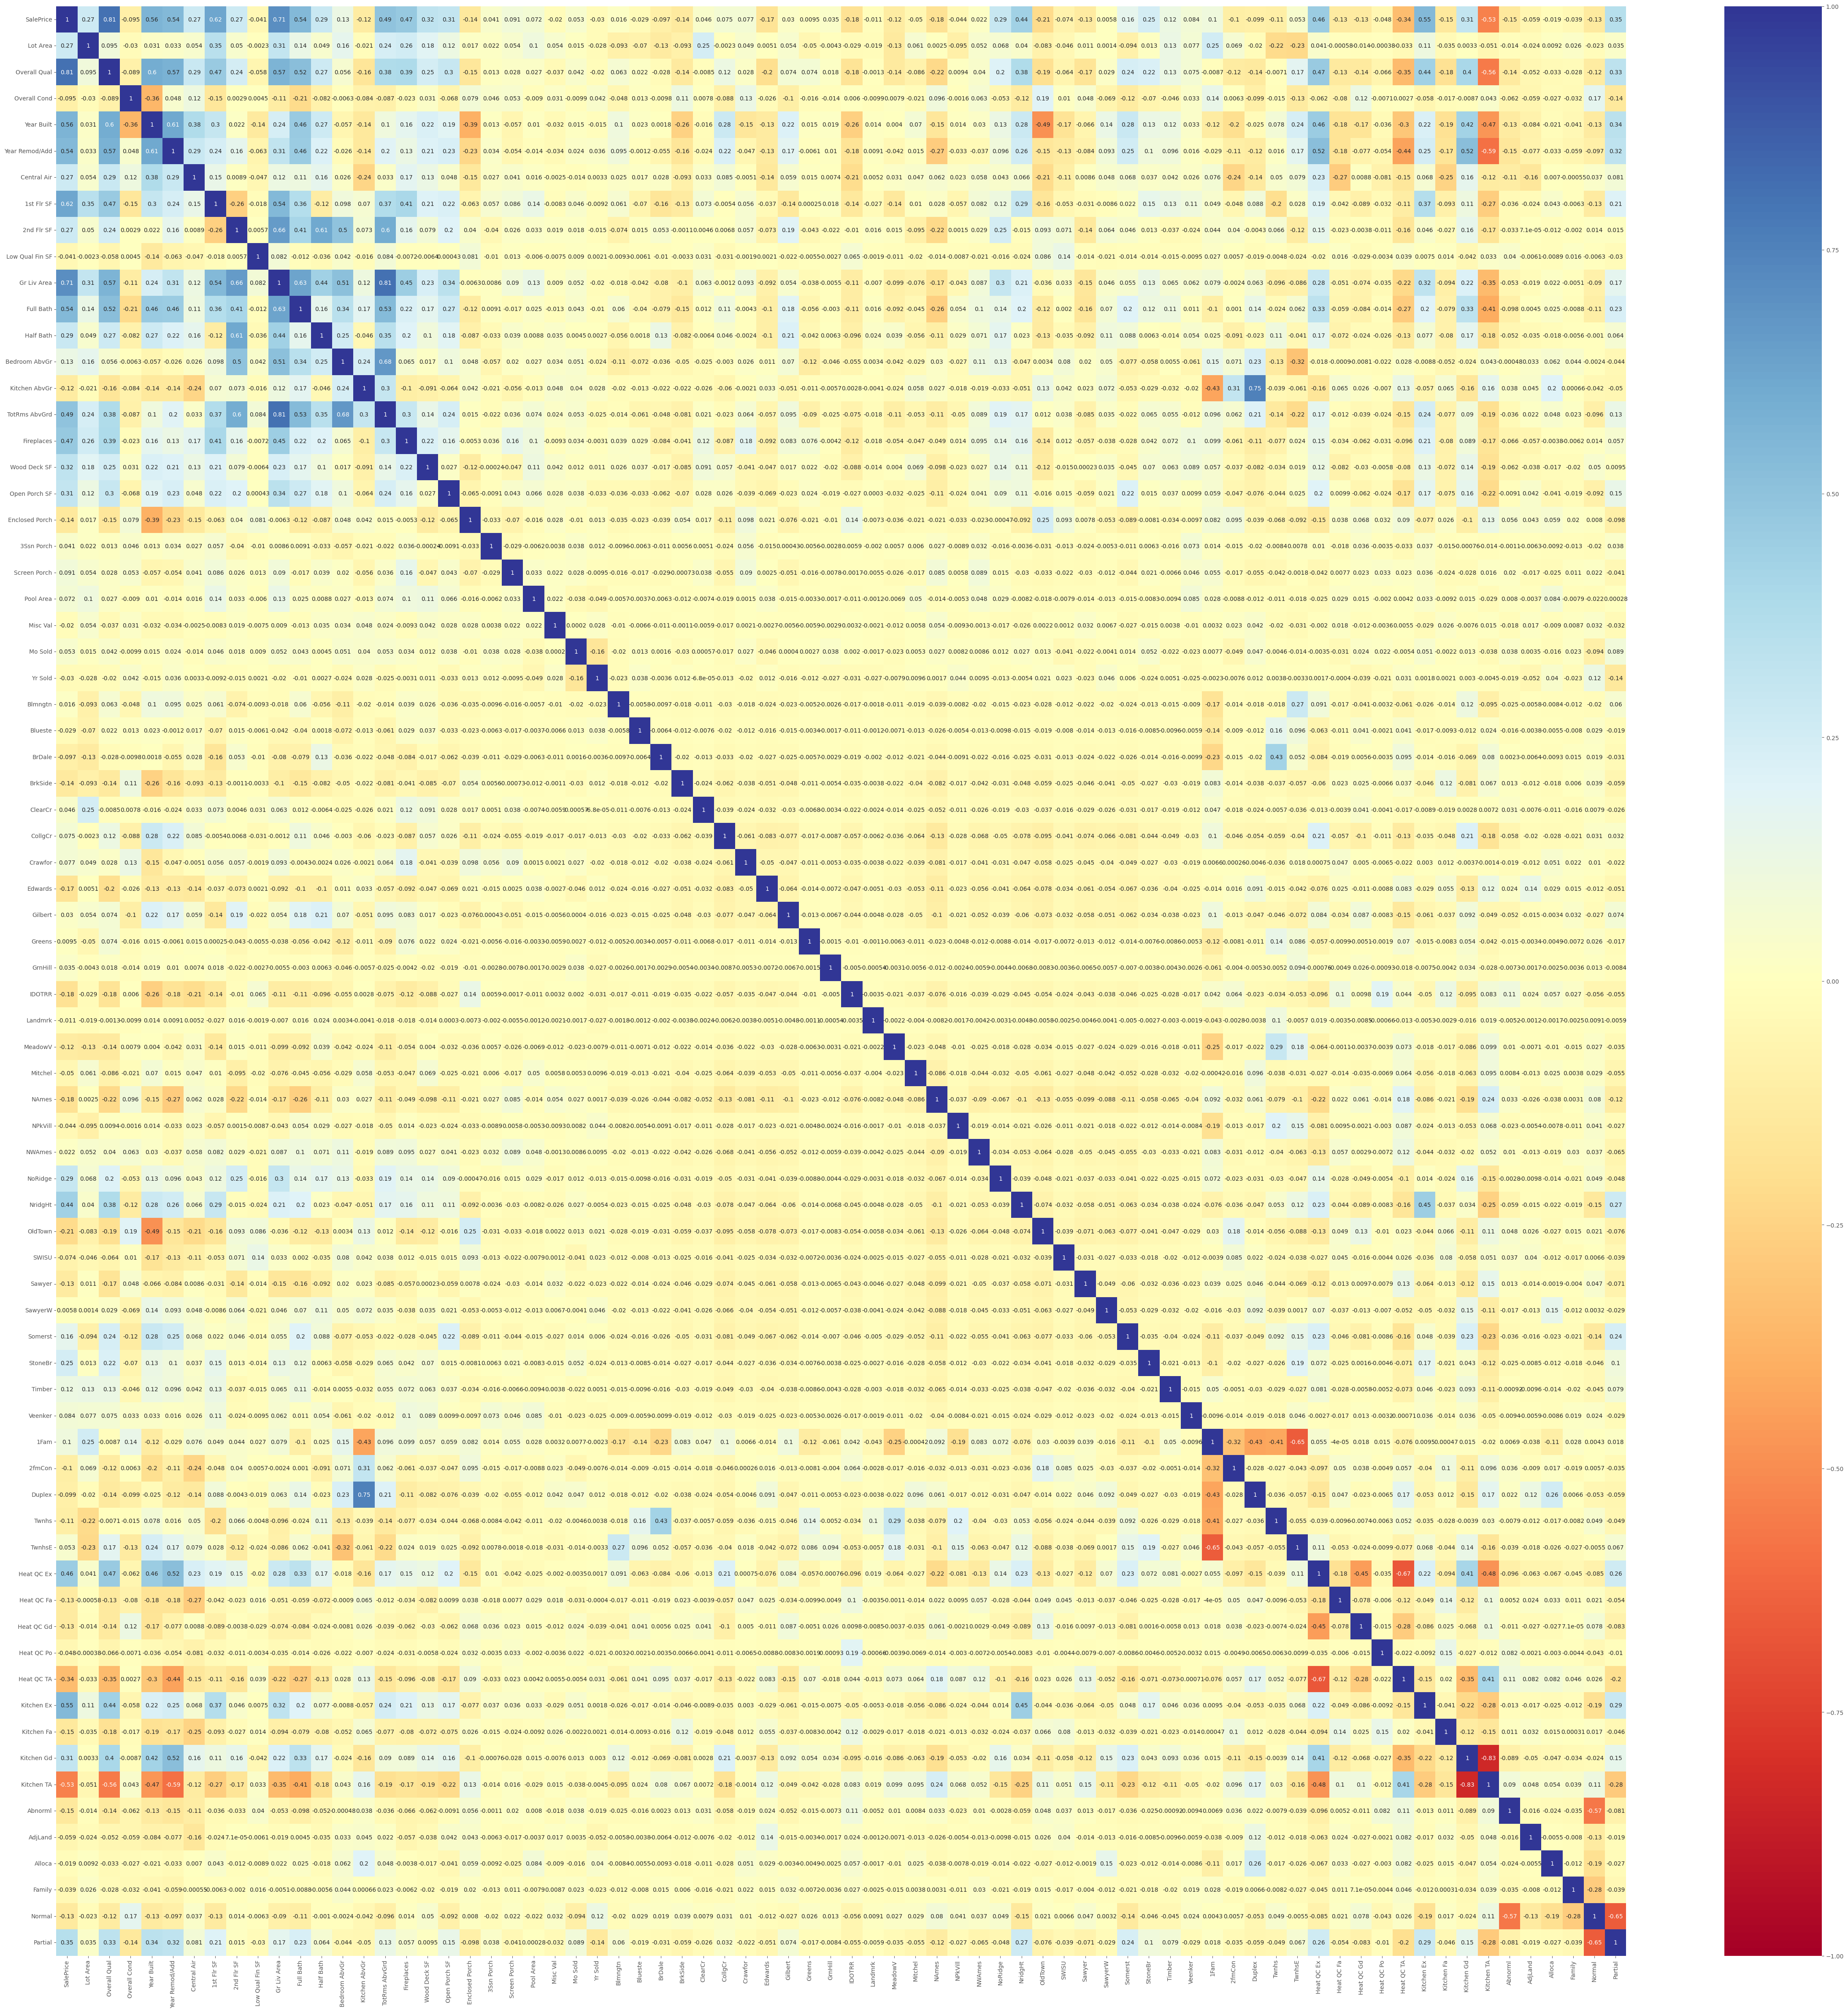

In [380]:
fig, subplot = plt.subplots(figsize=(60,60))
subplot.set_facecolor("black")
sns.heatmap(
  corr,
  cmap='RdYlBu',
  annot = True,
  vmin = -1,
  vmax = 1,
  ax=subplot,
);

Based on the intial analysis, I subselected features that correlated with SalePrice at 0.25 or higher or -0.25 or lower.

These features were:
* Lot Area (0.27)
* Overall Qual (0.81)
* Year Built (0.56)
* Year Remod/Add (0.54)
* Central Air (0.27)
* 1st Flr SF (0.62)
* 2nd Flr Sf (0.27)
* Gr Liv Area (0.71)
* Full Bath (0.54)
* Half Bath (0.29)
* TotRms AbvGrd (0.49)
* Fireplaces (0.47)
* Wood Deck SF (0.32)
* Open Porch SF (0.31)
* NoRidge (0.29)
* NridgHt (0.44)
* StoneBr (0.25)
* Heat QC Ex (0.46)
* Heat QC TA (-0.34)
* Kitchen Ex (0.55)
* Kitchen Gd (0.31)
* Kitchen TA (-0.53)
* Partial (0.35)


In [381]:
housing_dfcleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 74 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   SalePrice        2637 non-null   int64
 1   Lot Area         2637 non-null   int64
 2   Overall Qual     2637 non-null   int64
 3   Overall Cond     2637 non-null   int64
 4   Year Built       2637 non-null   int64
 5   Year Remod/Add   2637 non-null   int64
 6   Central Air      2637 non-null   int64
 7   1st Flr SF       2637 non-null   int64
 8   2nd Flr SF       2637 non-null   int64
 9   Low Qual Fin SF  2637 non-null   int64
 10  Gr Liv Area      2637 non-null   int64
 11  Full Bath        2637 non-null   int64
 12  Half Bath        2637 non-null   int64
 13  Bedroom AbvGr    2637 non-null   int64
 14  Kitchen AbvGr    2637 non-null   int64
 15  TotRms AbvGrd    2637 non-null   int64
 16  Fireplaces       2637 non-null   int64
 17  Wood Deck SF     2637 non-null   int64
 18  Open Por

In [382]:
housing_dfcleaned = housing_dfcleaned.drop(columns=['Abnorml', 'AdjLand', 'Alloca', 'Family', 'Normal'])

In [383]:
housing_dfcleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 69 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   SalePrice        2637 non-null   int64
 1   Lot Area         2637 non-null   int64
 2   Overall Qual     2637 non-null   int64
 3   Overall Cond     2637 non-null   int64
 4   Year Built       2637 non-null   int64
 5   Year Remod/Add   2637 non-null   int64
 6   Central Air      2637 non-null   int64
 7   1st Flr SF       2637 non-null   int64
 8   2nd Flr SF       2637 non-null   int64
 9   Low Qual Fin SF  2637 non-null   int64
 10  Gr Liv Area      2637 non-null   int64
 11  Full Bath        2637 non-null   int64
 12  Half Bath        2637 non-null   int64
 13  Bedroom AbvGr    2637 non-null   int64
 14  Kitchen AbvGr    2637 non-null   int64
 15  TotRms AbvGrd    2637 non-null   int64
 16  Fireplaces       2637 non-null   int64
 17  Wood Deck SF     2637 non-null   int64
 18  Open Por

In [384]:
housing_dfcleaned2 = housing_dfcleaned.drop(housing_dfcleaned.columns[[3, 9, 13, 14, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28 ,29, 30, 31 ,32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 46, 47, 48, 49, 50, 52, 53, 54, 55, 56, 57, 58, 60, 61 ,62, 65]], axis=1)

In [385]:
housing_dfcleaned2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   SalePrice       2637 non-null   int64
 1   Lot Area        2637 non-null   int64
 2   Overall Qual    2637 non-null   int64
 3   Year Built      2637 non-null   int64
 4   Year Remod/Add  2637 non-null   int64
 5   Central Air     2637 non-null   int64
 6   1st Flr SF      2637 non-null   int64
 7   2nd Flr SF      2637 non-null   int64
 8   Gr Liv Area     2637 non-null   int64
 9   Full Bath       2637 non-null   int64
 10  Half Bath       2637 non-null   int64
 11  TotRms AbvGrd   2637 non-null   int64
 12  Fireplaces      2637 non-null   int64
 13  Wood Deck SF    2637 non-null   int64
 14  Open Porch SF   2637 non-null   int64
 15  NoRidge         2637 non-null   int64
 16  NridgHt         2637 non-null   int64
 17  StoneBr         2637 non-null   int64
 18  Heat QC Ex      2637 non-nul

In [386]:
corr2 = housing_dfcleaned2.corr()
corr2

,SalePrice,Lot Area,Overall Qual,Year Built,Year Remod/Add,Central Air,1st Flr SF,2nd Flr SF,Gr Liv Area,Full Bath,...,Open Porch SF,NoRidge,NridgHt,StoneBr,Heat QC Ex,Heat QC TA,Kitchen Ex,Kitchen Gd,Kitchen TA,Partial
SalePrice,1.000000,0.268516,0.805016,0.562777,0.539932,0.269512,0.618247,0.268059,0.705482,0.542386,...,0.310361,0.291620,0.435747,0.245283,0.455890,-0.342162,0.546468,0.305150,-0.533564,0.353296
Lot Area,0.268516,1.000000,0.095071,0.030558,0.032820,0.054431,0.347911,0.049998,0.311768,0.137790,...,0.118606,0.068439,0.039994,0.013107,0.040677,-0.032772,0.113135,0.003342,-0.050598,0.035377
Overall Qual,0.805016,0.095071,1.000000,0.595225,0.571035,0.286985,0.467009,0.244258,0.566552,0.519857,...,0.295126,0.203916,0.377488,0.221317,0.466629,-0.347526,0.436725,0.399199,-0.559431,0.331320
Year Built,0.562777,0.030558,0.595225,1.000000,0.614758,0.378505,0.298960,0.022109,0.237357,0.462647,...,0.186176,0.127467,0.278036,0.127043,0.460276,-0.298277,0.224191,0.421912,-0.472121,0.339117
Year Remod/Add,0.539932,0.032820,0.571035,0.614758,1.000000,0.286357,0.236601,0.159637,0.314967,0.458367,...,0.233864,0.095542,0.256332,0.100869,0.519451,-0.435415,0.248992,0.523324,-0.590629,0.323907
Central Air,0.269512,0.054431,0.286985,0.378505,0.286357,1.000000,0.147442,0.008866,0.117277,0.113158,...,0.047780,0.042642,0.065876,0.036909,0.230287,-0.148800,0.067516,0.159729,-0.117991,0.081327
1st Flr SF,0.618247,0.347911,0.467009,0.298960,0.236601,0.147442,1.000000,-0.261955,0.544693,0.362286,...,0.219278,0.116205,0.292522,0.149782,0.186009,-0.114276,0.365951,0.113473,-0.270134,0.207576
2nd Flr SF,0.268059,0.049998,0.244258,0.022109,0.159637,0.008866,-0.261955,1.000000,0.661897,0.409485,...,0.199371,0.249425,-0.014643,0.012757,0.154838,-0.157253,0.046270,0.155226,-0.167506,0.015281
Gr Liv Area,0.705482,0.311768,0.566552,0.237357,0.314967,0.117277,0.544693,0.661897,1.000000,0.632506,...,0.341662,0.303787,0.211134,0.125496,0.275662,-0.220602,0.323383,0.217913,-0.350365,0.170832
Full Bath,0.542386,0.137790,0.519857,0.462647,0.458367,0.113158,0.362286,0.409485,0.632506,1.000000,...,0.268438,0.140584,0.196574,0.115243,0.333216,-0.274325,0.200277,0.333909,-0.405657,0.232750


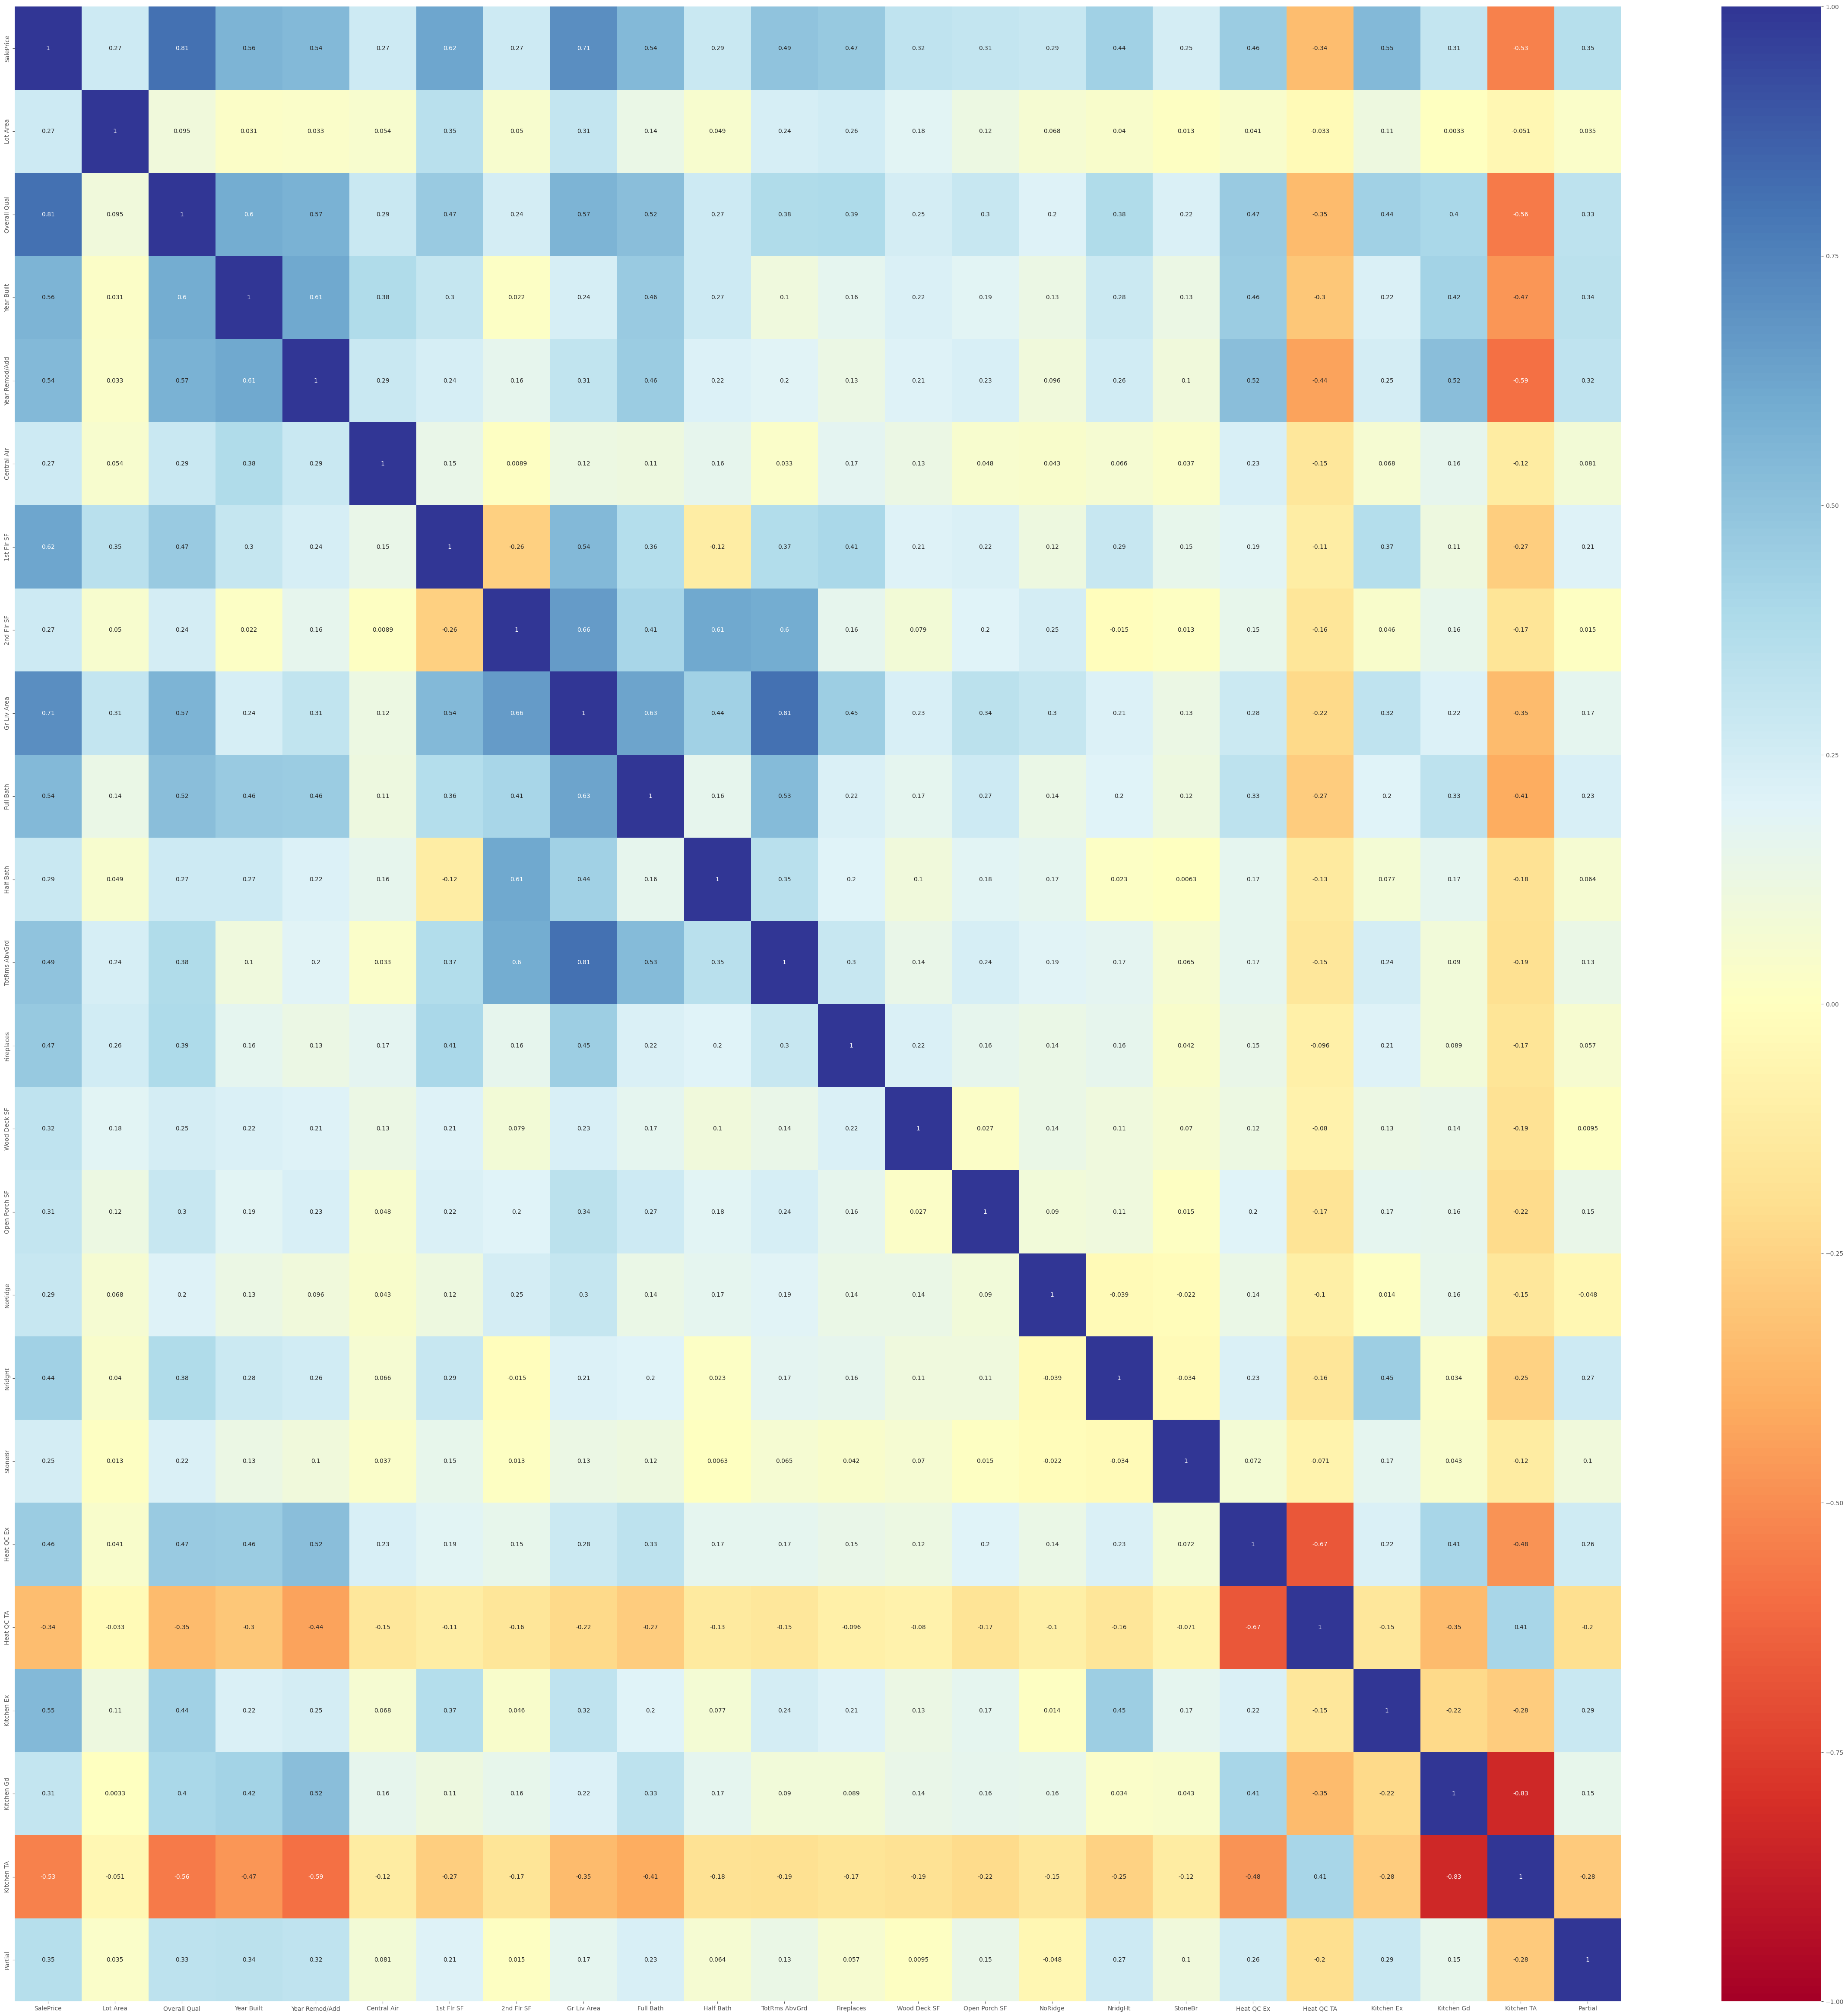

In [387]:
fig, subplot = plt.subplots(figsize=(60,60))
subplot.set_facecolor("black")
sns.heatmap(
  corr2,
  cmap='RdYlBu',
  annot = True,
  vmin = -1,
  vmax = 1,
  ax=subplot,
);

### Testing for Colinearity

Now that the dataframe has been reduced down to the features correlated with sales price, I looked for features correlated to each other.

In [388]:
np.set_printoptions(linewidth=200, suppress=True)

ones = np.ones_like(
    corr2,
    dtype=bool,
)
ones

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  T

In [389]:
mask = np.tril(ones, k=-1)
mask

array([[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True,  True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True,  True,  True,  True, False, False, False, False, False, False, False, False, False, False, Fa

In [390]:
lower_triangle_corr = corr2.where(mask)
lower_triangle_corr

,SalePrice,Lot Area,Overall Qual,Year Built,Year Remod/Add,Central Air,1st Flr SF,2nd Flr SF,Gr Liv Area,Full Bath,...,Open Porch SF,NoRidge,NridgHt,StoneBr,Heat QC Ex,Heat QC TA,Kitchen Ex,Kitchen Gd,Kitchen TA,Partial
SalePrice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Area,0.268516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Overall Qual,0.805016,0.095071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year Built,0.562777,0.030558,0.595225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year Remod/Add,0.539932,0.032820,0.571035,0.614758,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Central Air,0.269512,0.054431,0.286985,0.378505,0.286357,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1st Flr SF,0.618247,0.347911,0.467009,0.298960,0.236601,0.147442,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2nd Flr SF,0.268059,0.049998,0.244258,0.022109,0.159637,0.008866,-0.261955,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gr Liv Area,0.705482,0.311768,0.566552,0.237357,0.314967,0.117277,0.544693,0.661897,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Full Bath,0.542386,0.137790,0.519857,0.462647,0.458367,0.113158,0.362286,0.409485,0.632506,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


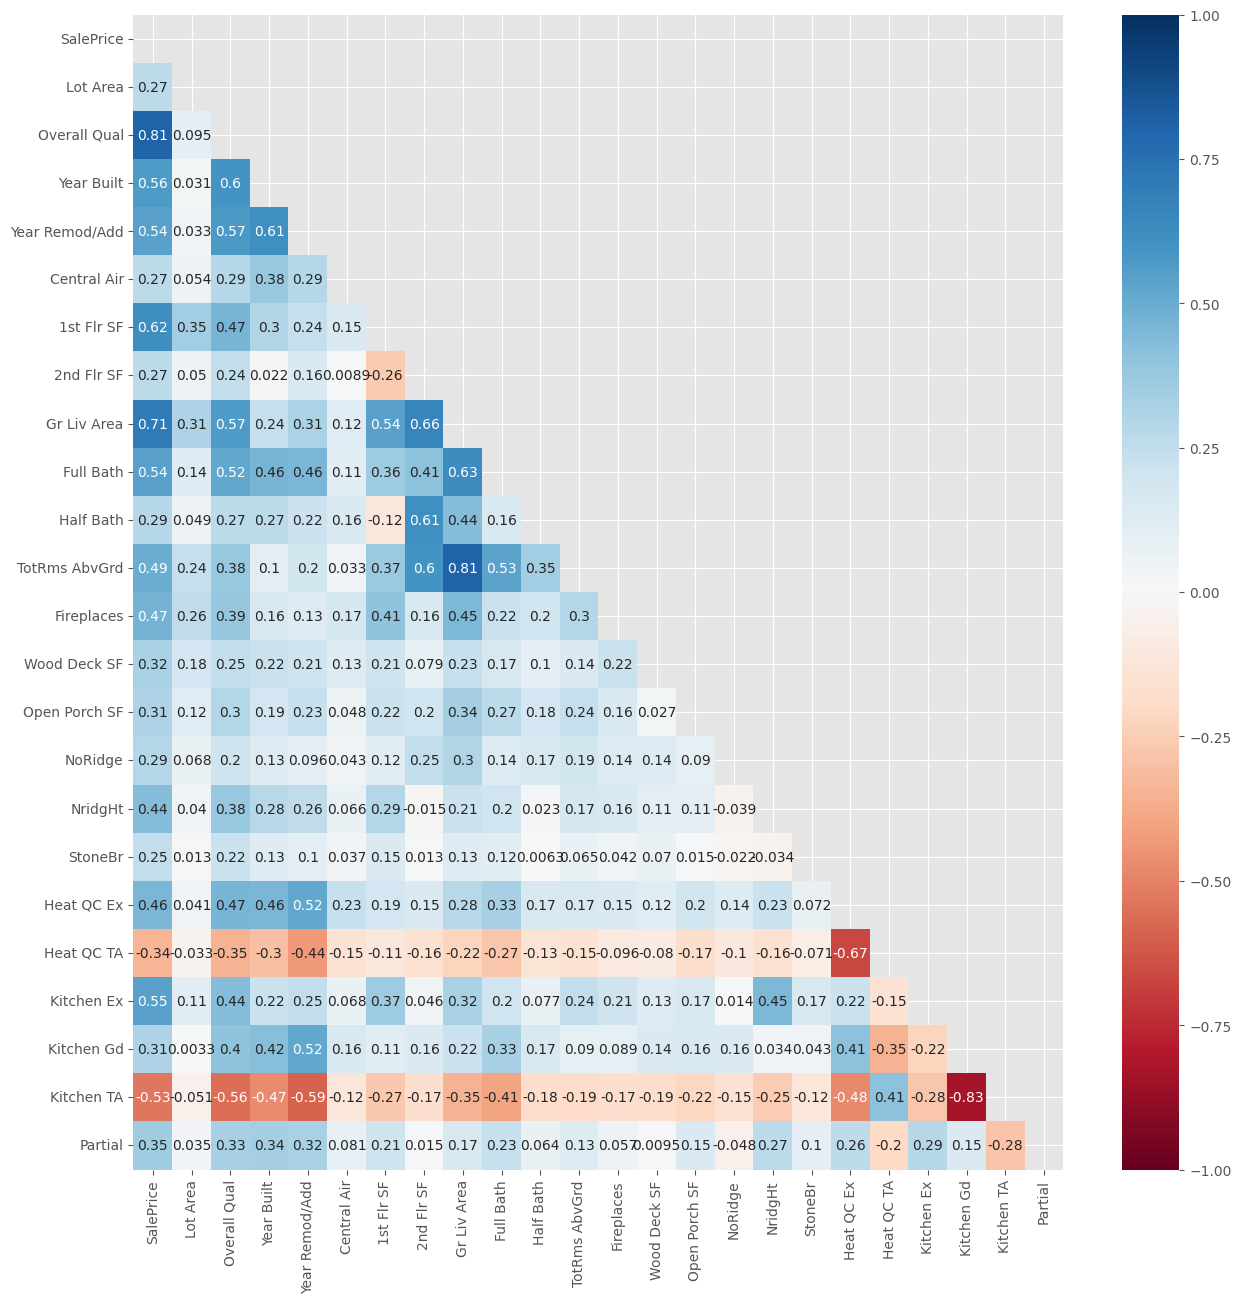

In [391]:
plt.figure(figsize=(15,15))
sns.heatmap(
    data=lower_triangle_corr,
    annot=True,
    vmin=-1,
    vmax=1,
    cmap='RdBu'
) ;

In [392]:
lt_df1 = (
  lower_triangle_corr
  .unstack()
  .to_frame()
  .rename( columns={0:"A"} )
  .query( "A > 0.75")
  .sort_values( by = "A", ascending=False )
  .reset_index()
)
lt_df1

,level_0,level_1,A
0,Gr Liv Area,TotRms AbvGrd,0.807065
1,SalePrice,Overall Qual,0.805016


In [393]:
lt_df2 = (
  lower_triangle_corr
  .unstack()
  .to_frame()
  .rename( columns={0:"B"} )
  .query( "B < -0.75")
  .sort_values( by = "B", ascending=False )
  .reset_index()
)
lt_df2

,level_0,level_1,B
0,Kitchen Gd,Kitchen TA,-0.829344


None of the correlation values are above 0.9 or below -0.9, so none of the features are highly correlated.  So all will be retained.  This review of the features violate the collinearity requirement for Multiple Linear Regression.

### Looking for linearity and outliers

Next, scatterplots were created to look for a linear relationship and outliers

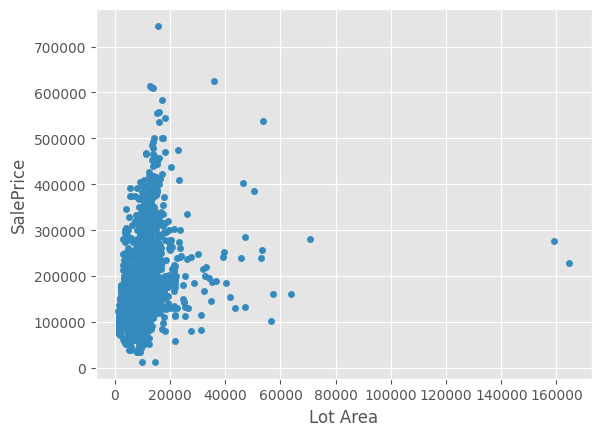

In [394]:
housing_dfcleaned2.plot('Lot Area', 'SalePrice', kind = 'scatter');

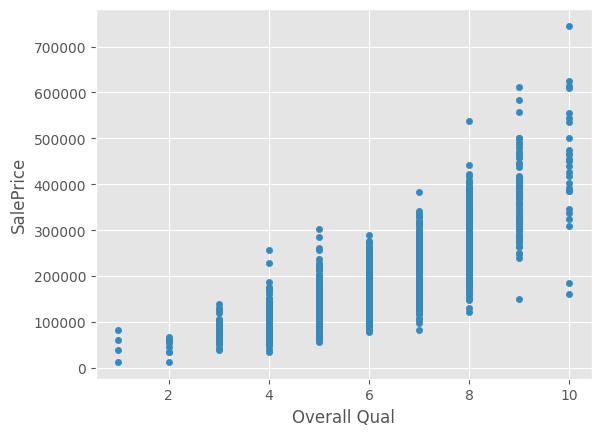

In [395]:
housing_dfcleaned2.plot('Overall Qual', 'SalePrice', kind = 'scatter');

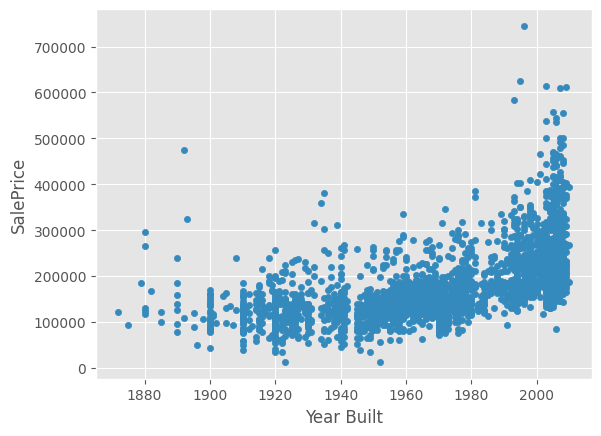

In [396]:
housing_dfcleaned2.plot('Year Built', 'SalePrice', kind = 'scatter');

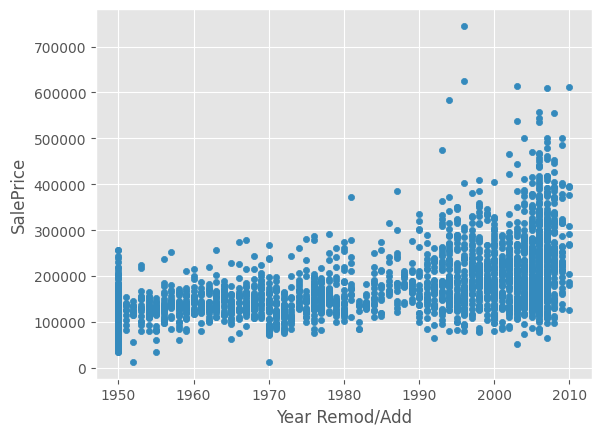

In [397]:
housing_dfcleaned2.plot('Year Remod/Add', 'SalePrice', kind = 'scatter');

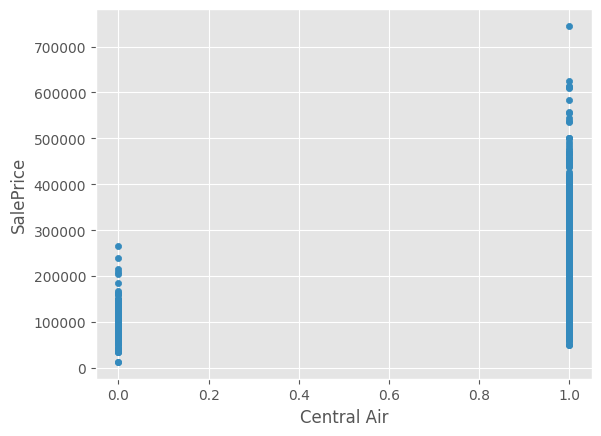

In [398]:
housing_dfcleaned2.plot('Central Air', 'SalePrice', kind = 'scatter');

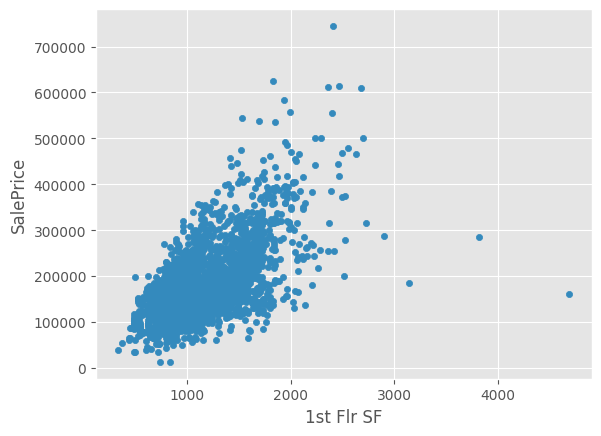

In [399]:
housing_dfcleaned2.plot('1st Flr SF', 'SalePrice', kind = 'scatter');

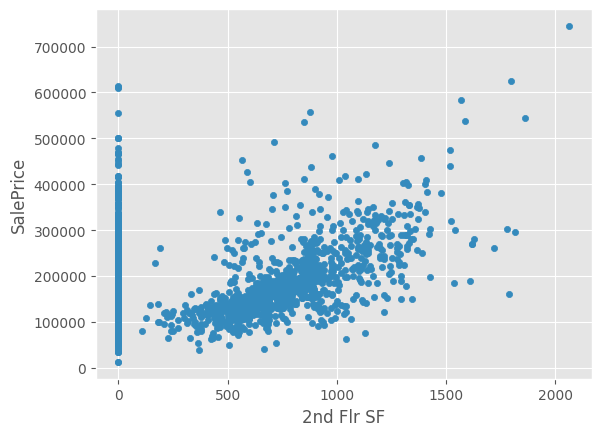

In [400]:
housing_dfcleaned2.plot('2nd Flr SF', 'SalePrice', kind = 'scatter');

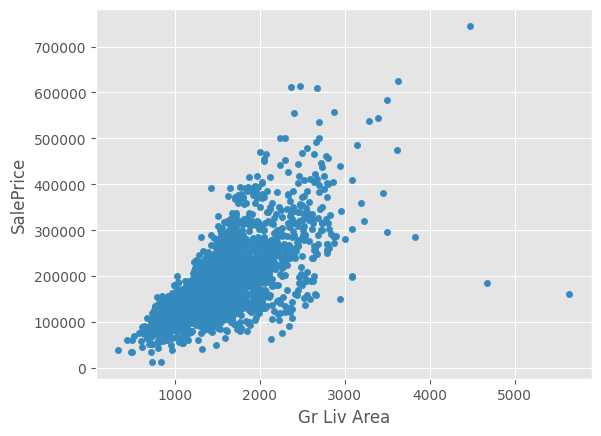

In [401]:
housing_dfcleaned2.plot('Gr Liv Area', 'SalePrice', kind = 'scatter');

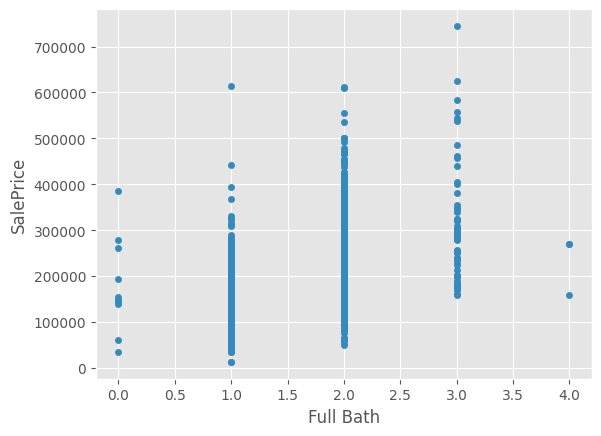

In [402]:
housing_dfcleaned2.plot('Full Bath', 'SalePrice', kind = 'scatter');

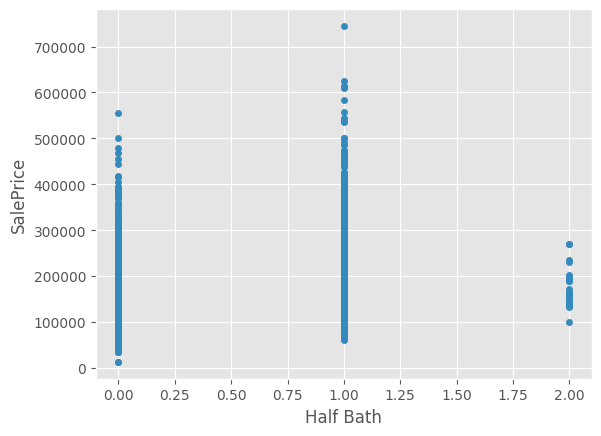

In [403]:
housing_dfcleaned2.plot('Half Bath', 'SalePrice', kind = 'scatter');

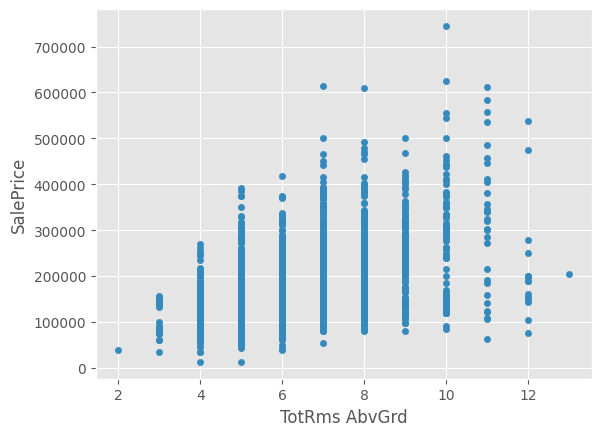

In [404]:
housing_dfcleaned2.plot('TotRms AbvGrd', 'SalePrice', kind = 'scatter');

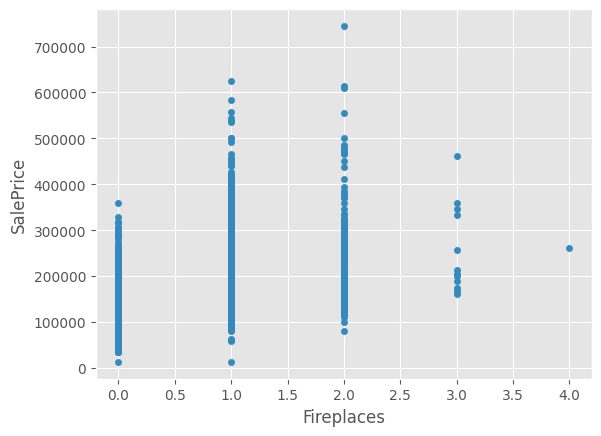

In [405]:
housing_dfcleaned2.plot('Fireplaces', 'SalePrice', kind = 'scatter');

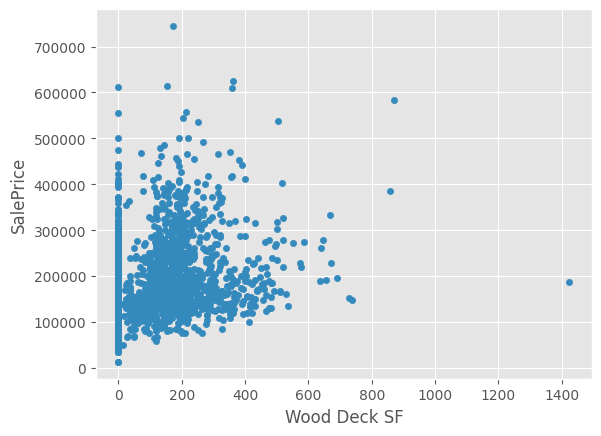

In [406]:
housing_dfcleaned2.plot('Wood Deck SF', 'SalePrice', kind = 'scatter');

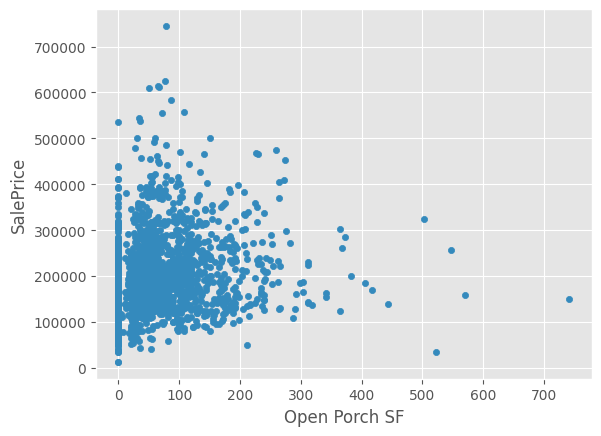

In [407]:
housing_dfcleaned2.plot('Open Porch SF', 'SalePrice', kind = 'scatter');

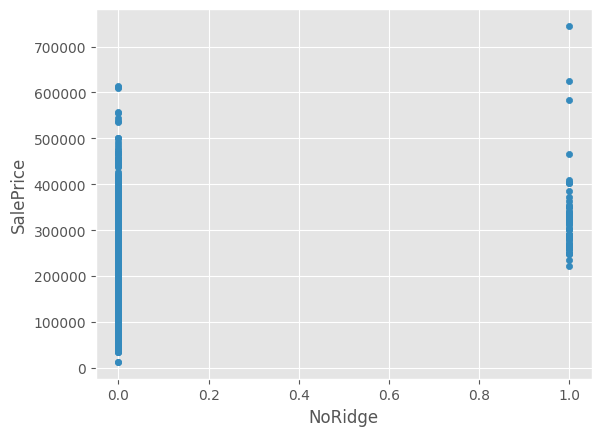

In [408]:
housing_dfcleaned2.plot('NoRidge', 'SalePrice', kind = 'scatter');

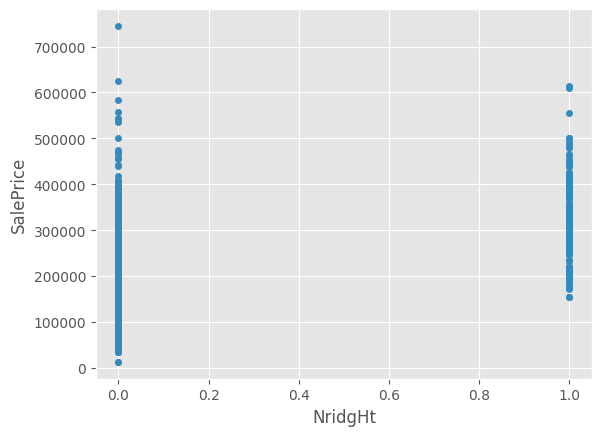

In [409]:
housing_dfcleaned2.plot('NridgHt', 'SalePrice', kind = 'scatter');

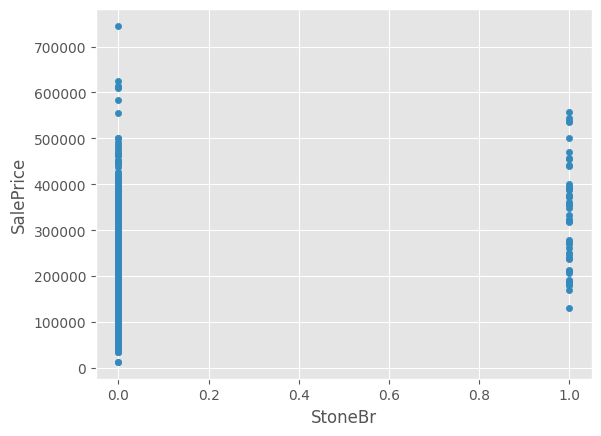

In [410]:
housing_dfcleaned2.plot('StoneBr', 'SalePrice', kind = 'scatter');

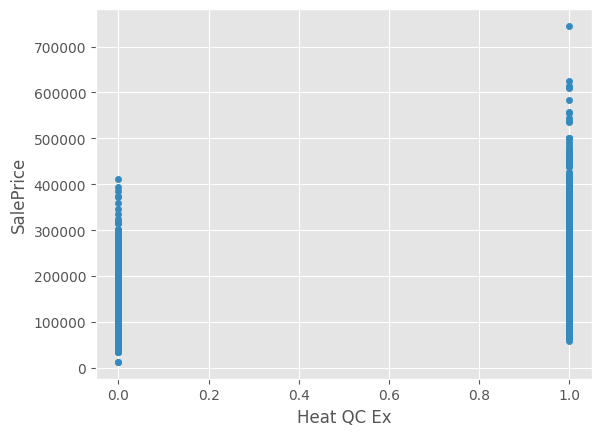

In [411]:
housing_dfcleaned2.plot('Heat QC Ex', 'SalePrice', kind = 'scatter');

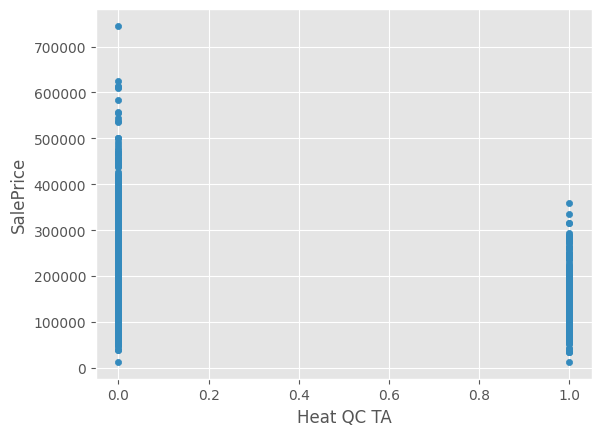

In [412]:
housing_dfcleaned2.plot('Heat QC TA', 'SalePrice', kind = 'scatter');

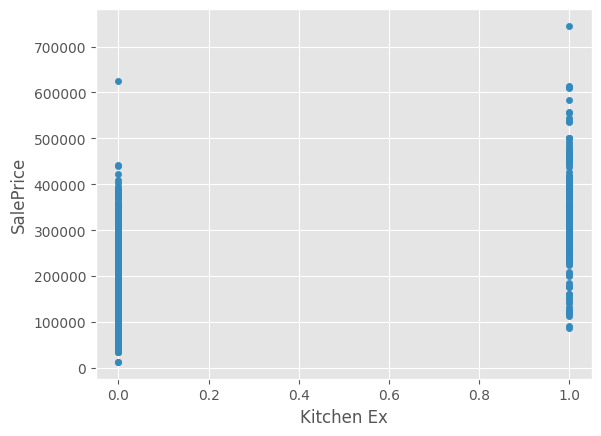

In [413]:
housing_dfcleaned2.plot('Kitchen Ex', 'SalePrice', kind = 'scatter');

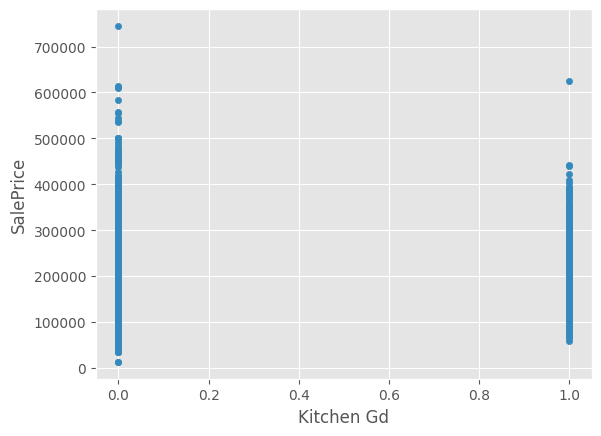

In [414]:
housing_dfcleaned2.plot('Kitchen Gd', 'SalePrice', kind = 'scatter');

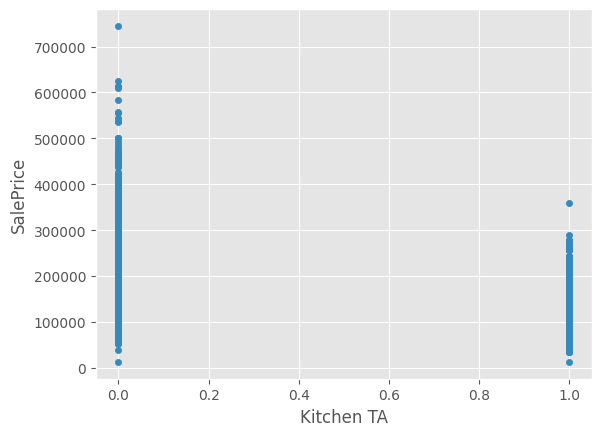

In [415]:
housing_dfcleaned2.plot('Kitchen TA', 'SalePrice', kind = 'scatter');

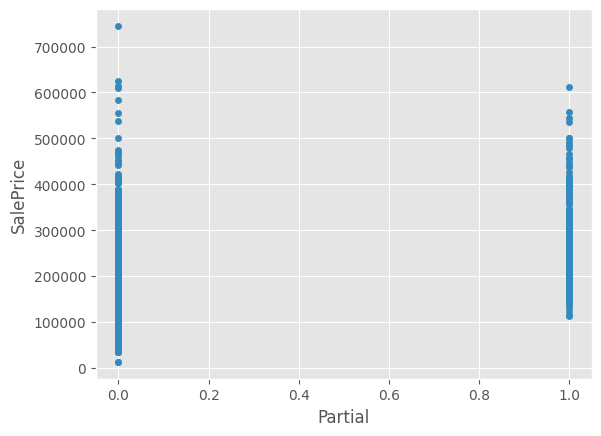

In [416]:
housing_dfcleaned2.plot('Partial', 'SalePrice', kind = 'scatter');

The various features appear to have a linear relationship with the Sales Price so these features due meet the criteria for Multiple Linear Regression.  However, several of the features have outliers.  Features with outliers include: Lot Area, 1st Floor SF, 2nd Floor SF, Ground Floor Living Area, Fireplaces, Wood Deck SF and Open Porch SF.  

The outliers mean that data transformation will be required during processing.

## Data Processing

The model will be created with columns included based on the correlation with Sales Price.  The first iteration will include all of the features just explored which are correlated with Sale Price at |0.25|.  Future iterations will use more limited datasets with other correlation cut off vales.

### Multiple Linear Regression with correlation cut off of |0.25|

Multiple Linear regression will be explored with and without regularization.

In [417]:
X = housing_dfcleaned2.drop(['SalePrice'], axis = 1).copy()
y = housing_dfcleaned2['SalePrice']

scaler = StandardScaler()
scaler.fit_transform(X)

array([[ 0.63108356, -1.48623738, -0.24053754, ..., -0.8146916 ,  0.98233276, -0.30319213],
       [ 0.11070691, -1.48623738, -0.14153169, ..., -0.8146916 ,  0.98233276, -0.30319213],
       [-0.15497   , -0.06905858, -1.1315902 , ...,  1.22745835, -1.01798499, -0.30319213],
       ...,
       [-0.92900801,  1.34812022,  0.32049562, ...,  1.22745835, -1.01798499, -0.30319213],
       [ 0.01413758, -0.06905858,  0.08948197, ..., -0.8146916 ,  0.98233276, -0.30319213],
       [ 0.35828634,  0.63953082,  0.91453073, ..., -0.8146916 ,  0.98233276, -0.30319213]])

In [418]:
X.columns

Index(['Lot Area', 'Overall Qual', 'Year Built', 'Year Remod/Add',
       'Central Air', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Full Bath',
       'Half Bath', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF',
       'Open Porch SF', 'NoRidge', 'NridgHt', 'StoneBr', 'Heat QC Ex',
       'Heat QC TA', 'Kitchen Ex', 'Kitchen Gd', 'Kitchen TA', 'Partial'],
      dtype='object')

In [419]:
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=5)

In [420]:
model = LinearRegression()
my_fit_lr = model.fit(X_train, y_train)

In [421]:
model_results = pd.DataFrame()
model_results['Predictor'] = X_train.columns
model_results['Linear'] = my_fit_lr.coef_
model_results.sort_values(by=['Linear'],inplace=True, ascending=False)
model_results

,Predictor,Linear
1,Overall Qual,22311.551407
5,1st Flr SF,19395.159818
19,Kitchen Ex,11979.619084
6,2nd Flr SF,10819.382541
2,Year Built,8132.516380
14,NoRidge,8124.082791
15,NridgHt,7724.104166
7,Gr Liv Area,6705.903384
16,StoneBr,6705.158641
11,Fireplaces,5948.951586


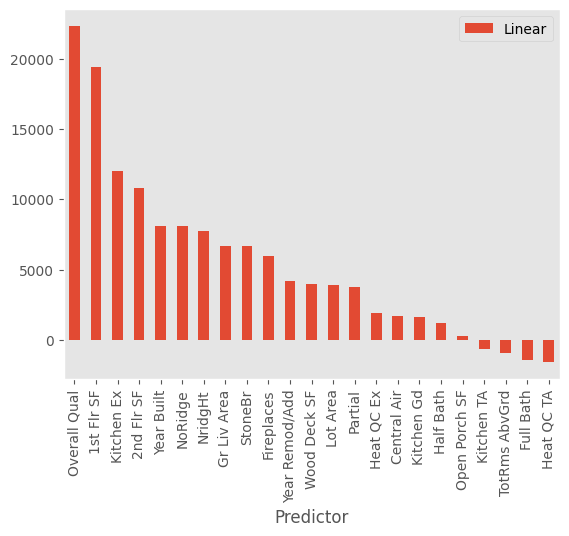

In [422]:
model_results.plot(x = 'Predictor', y = 'Linear', kind = 'bar')
plt.grid()

In [423]:
results = cross_val_score(
    model,
    X_scaled,
    y,
    scoring='neg_root_mean_squared_error',
    cv = 10
    )
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 30679.850855108794


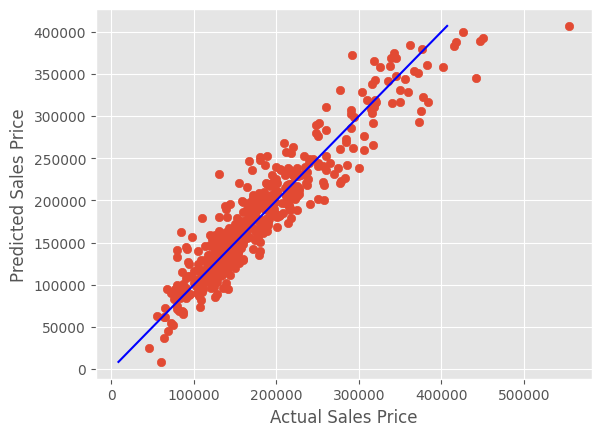

In [424]:
y_pred = my_fit_lr.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

The RMSPE will be calculated next

In [425]:
(((y_test - y_pred) / y_test) **2).mean()**(1/2) * 100

np.float64(16.7035929248926)

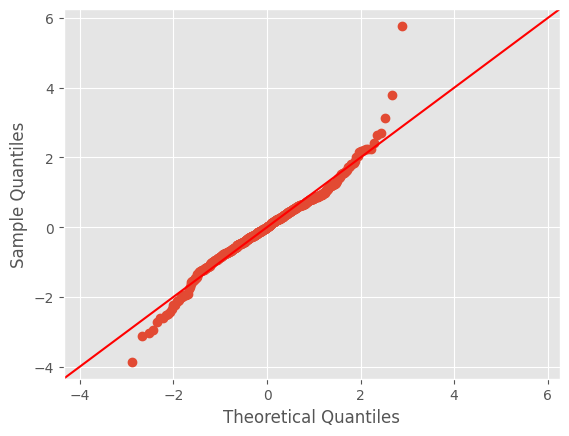

In [426]:
res = y_test - y_pred
sm.qqplot(res, fit=True, line="45") ;

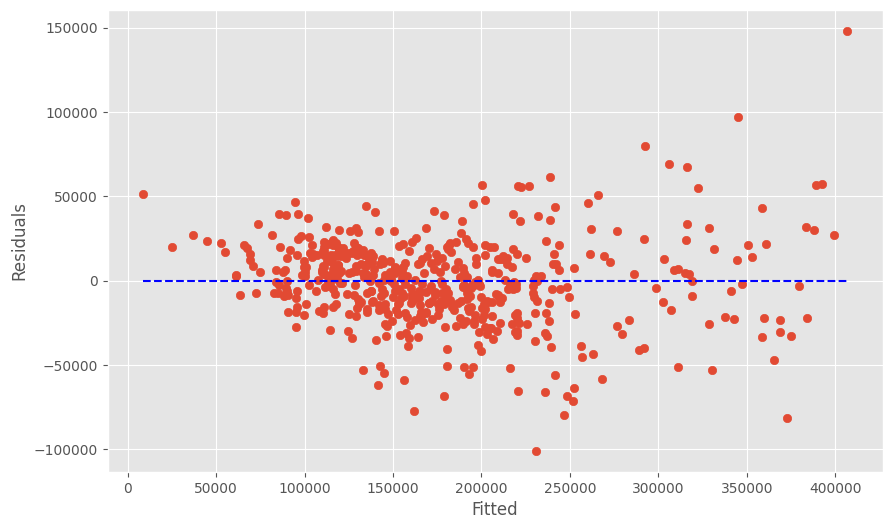

In [427]:
plt.figure(figsize = (10,6))
plt.scatter(y_pred, res)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.hlines(0, min(y_pred), max(y_pred), colors = 'blue', linestyles = 'dashed') ;

This first run shows that there is a RMSE of ~30K.  Additionally, the residual plot shows that the residual distribution is not normal, suggesting the data will need to be regularized for analysis.

Next, Ridge Regression will be assessed

In [428]:
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000]

# Create empty list to hold results
results_alpha = []

for i in alpha:
  # Train the model
  my_fit_rr = Ridge(alpha = i) # Looping through alpha
  my_fit_rr.fit(X_train, y_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_rr,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
      )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

           Alpha          RMSE
15  5.000000e+01  30661.616797
14  3.000000e+01  30663.610352
13  2.000000e+01  30666.157659
16  1.000000e+02  30669.885006
12  1.000000e+01  30670.198517
11  5.000000e+00  30673.361111
10  4.000000e+00  30674.214808
9   3.000000e+00  30675.206149
8   2.000000e+00  30676.395598
7   1.000000e+00  30677.884200
6   1.000000e-01  30679.624865
5   1.000000e-02  30679.827907
4   1.000000e-03  30679.848557
3   1.000000e-04  30679.850625
2   1.000000e-08  30679.850855
1   1.000000e-10  30679.850855
0   1.000000e-15  30679.850855
17  2.000000e+02  30722.869590
18  3.000000e+02  30804.935651
19  5.000000e+02  31016.997466
20  1.000000e+03  31682.544755


In [429]:
results_df.sort_values( by = ["Alpha"])

,Alpha,RMSE
0,1.000000e-15,30679.850855
1,1.000000e-10,30679.850855
2,1.000000e-08,30679.850855
3,1.000000e-04,30679.850625
4,1.000000e-03,30679.848557
5,1.000000e-02,30679.827907
6,1.000000e-01,30679.624865
7,1.000000e+00,30677.884200
8,2.000000e+00,30676.395598
9,3.000000e+00,30675.206149


Alpha of 50 gives the lowest RSME, so it will be used for the model creation.

In [430]:
my_fit_rr = Ridge(alpha = 50)
my_fit_rr.fit(X_train, y_train)

# Calculate CV RMSE
results = cross_val_score(my_fit_rr, X_scaled, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 30661.616796514718


In [431]:
model_results['Ridge'] = my_fit_rr.coef_

In [432]:
model_results

,Predictor,Linear,Ridge
1,Overall Qual,22311.551407,3928.950376
5,1st Flr SF,19395.159818,21619.966555
19,Kitchen Ex,11979.619084,8027.889759
6,2nd Flr SF,10819.382541,4240.433406
2,Year Built,8132.516380,1873.343954
14,NoRidge,8124.082791,14080.023051
15,NridgHt,7724.104166,4763.578325
7,Gr Liv Area,6705.903384,12448.055540
16,StoneBr,6705.158641,-798.939008
11,Fireplaces,5948.951586,1509.586629


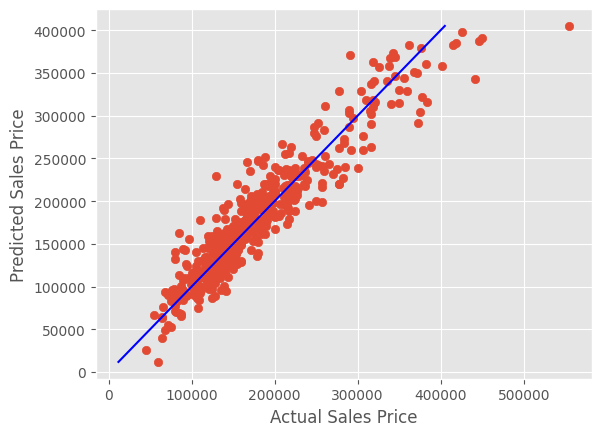

In [433]:
y_pred = my_fit_rr.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next RMSPE will be calculated

In [434]:
(((y_test - y_pred) / y_test) **2).mean()**(1/2) * 100

np.float64(16.54928473492109)

Next, Lasso Regularization will be assessed.

In [435]:
# Specify values of alpha we want to try
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000]

# Create empty list to hold results
results_alpha = []

for i in alpha:
  # Train the model
  my_fit_lasso = Lasso(alpha = i, tol = .01, max_iter=100_000) # Looping through alpha
  my_fit_lasso.fit(X_train, y_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_lasso,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
  )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.045e+12, tolerance: 1.325e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.127e+12, tolerance: 1.461e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.101e+12, tolerance: 1.438e

           Alpha          RMSE
16  1.000000e+02  30661.912905
17  2.000000e+02  30663.667323
18  3.000000e+02  30664.025917
19  5.000000e+02  30664.833229
15  5.000000e+01  30665.339074
14  3.000000e+01  30666.894321
13  2.000000e+01  30668.087899
12  1.000000e+01  30673.249140
11  5.000000e+00  30676.999604
10  4.000000e+00  30677.577517
9   3.000000e+00  30678.175818
8   2.000000e+00  30678.831755
7   1.000000e+00  30679.522446
6   1.000000e-01  30679.822555
5   1.000000e-02  30679.848008
4   1.000000e-03  30679.850571
3   1.000000e-04  30679.850826
2   1.000000e-08  30679.850855
1   1.000000e-10  30679.850855
0   1.000000e-15  30679.850855
20  1.000000e+03  30686.492997


In [436]:
results_df

,Alpha,RMSE
0,1.000000e-15,30679.850855
1,1.000000e-10,30679.850855
2,1.000000e-08,30679.850855
3,1.000000e-04,30679.850826
4,1.000000e-03,30679.850571
5,1.000000e-02,30679.848008
6,1.000000e-01,30679.822555
7,1.000000e+00,30679.522446
8,2.000000e+00,30678.831755
9,3.000000e+00,30678.175818


The lowest RSME is associated with alpha = 100, so this alpha will be used.

In [437]:
my_fit_lasso = Lasso(alpha = 100, tol = .01, max_iter=1000000)
my_fit_lasso.fit(X_train, y_train)

results = cross_val_score(my_fit_lasso, X_scaled, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 30661.912904675806


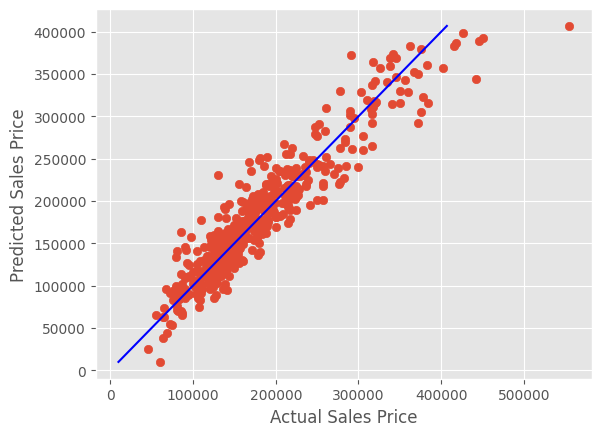

In [438]:
y_pred = my_fit_lasso.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next RMSPE will be calculated

In [439]:
(((y_test - y_pred) / y_test) **2).mean()**(1/2) * 100

np.float64(16.690834472253787)

In [440]:
model_results['Lasso'] = my_fit_lasso.coef_

In [441]:
model_results

,Predictor,Linear,Ridge,Lasso
1,Overall Qual,22311.551407,3928.950376,3837.429739
5,1st Flr SF,19395.159818,21619.966555,22352.463407
19,Kitchen Ex,11979.619084,8027.889759,7948.092907
6,2nd Flr SF,10819.382541,4240.433406,4099.350214
2,Year Built,8132.516380,1873.343954,1678.167840
14,NoRidge,8124.082791,14080.023051,20970.306723
15,NridgHt,7724.104166,4763.578325,12335.326758
7,Gr Liv Area,6705.903384,12448.055540,4315.714336
16,StoneBr,6705.158641,-798.939008,-963.175957
11,Fireplaces,5948.951586,1509.586629,1315.466192


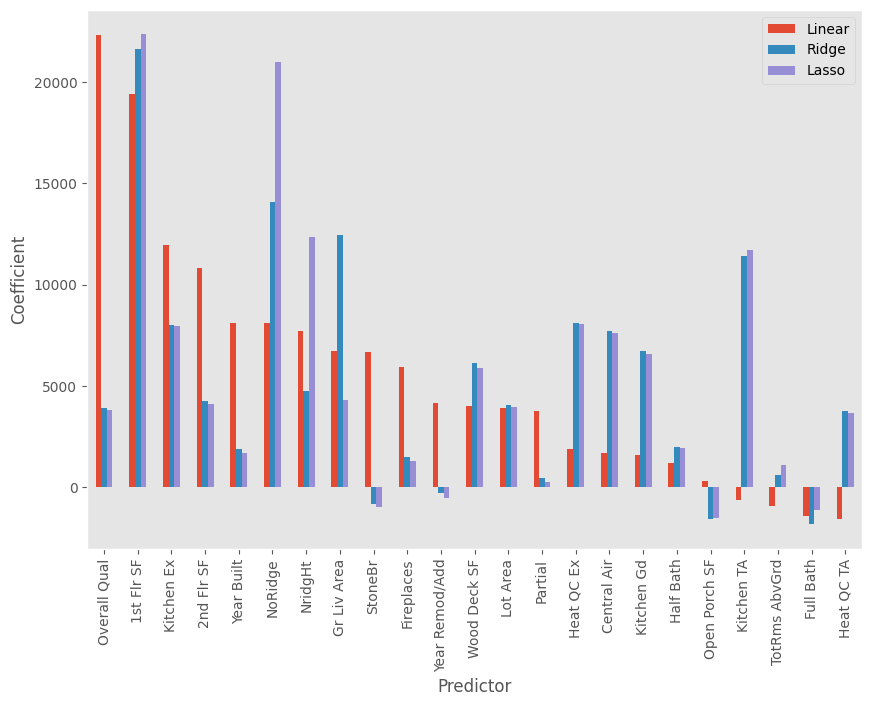

In [442]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
model_results.plot(x = 'Predictor', kind = 'bar', ax = ax)
ax.set_ylabel('Coefficient')
plt.grid()

### Multiple Linear Regression with correlation cut off of |0.7|

Multiple Linear regression will be explored with and without regularization.  Data will be reduced to only features that correlate with Sales Price at 0.7 or greater, which consist of only Overall Quality and Gr Living Area.

In [443]:
X2 = housing_dfcleaned2.drop(['Lot Area', 'Year Built', 'Year Remod/Add', 'Central Air', '1st Flr SF', '2nd Flr SF', 'Full Bath', 'Half Bath', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'NoRidge', 'NridgHt', 'StoneBr', 'Heat QC Ex', 'Heat QC TA', 'Kitchen Ex', 'Kitchen Gd', 'Kitchen TA', 'Partial', 'SalePrice'], axis = 1).copy()
y2 = housing_dfcleaned2['SalePrice']

scaler = StandardScaler()
scaler.fit_transform(X2)

array([[-1.48623738, -0.9936772 ],
       [-1.48623738, -0.40593582],
       [-0.06905858, -0.24637717],
       ...,
       [ 1.34812022, -0.54731691],
       [-0.06905858, -0.29687041],
       [ 0.63953082,  1.66630698]])

In [444]:
X2.columns

Index(['Overall Qual', 'Gr Liv Area'], dtype='object')

In [445]:
X2_scaled = pd.DataFrame(scaler.fit_transform(X2), columns=X2.columns)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size = 0.2, random_state=5)

In [446]:
model = LinearRegression()
my_fit_lr2 = model.fit(X2_train, y2_train)

In [447]:
model_results2 = pd.DataFrame()
model_results2['Predictor'] = X2_train.columns
model_results2['Linear'] = my_fit_lr2.coef_
model_results2.sort_values(by=['Linear'],inplace=True, ascending=False)
model_results2

,Predictor,Linear
0,Overall Qual,47322.064466
1,Gr Liv Area,28319.109156


In [448]:
results2 = cross_val_score(
    model,
    X2_scaled,
    y2,
    scoring='neg_root_mean_squared_error',
    cv = 10
    )
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 30661.912904675806


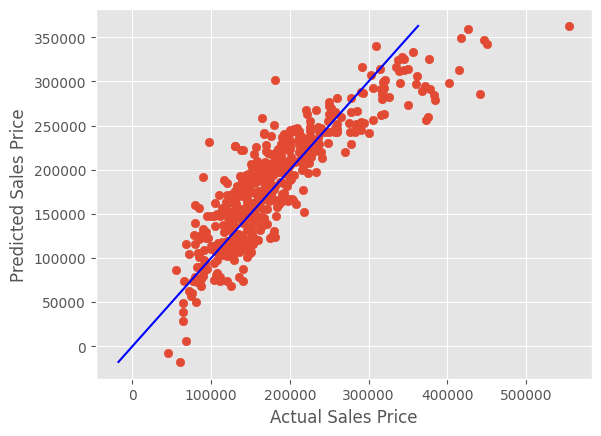

In [449]:
y2_pred = my_fit_lr2.predict(X2_test)
plt.scatter(y2_test, y2_pred)
plt.plot([min(y2_pred), max(y2_pred)],[min(y2_pred), max(y2_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next RMSPE will be calculated

In [450]:
(((y2_test - y2_pred) / y2_test) **2).mean()**(1/2) * 100

np.float64(24.618323609203895)

Next Ridge Regression on the reduced feature set will be done

In [451]:
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000]

# Create empty list to hold results
results_alpha = []

for i in alpha:
  # Train the model
  my_fit_rr2 = Ridge(alpha = i) # Looping through alpha
  my_fit_rr2.fit(X2_train, y2_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_rr2,
      X2_scaled,
      y2,
      scoring='neg_root_mean_squared_error',
      cv = 10
      )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df2 = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df2.sort_values(by=['RMSE']))

           Alpha          RMSE
12  1.000000e+01  39840.685724
11  5.000000e+00  39840.870681
10  4.000000e+00  39840.937477
9   3.000000e+00  39841.014261
13  2.000000e+01  39841.051727
8   2.000000e+00  39841.101059
7   1.000000e+00  39841.197892
6   1.000000e-01  39841.293642
5   1.000000e-02  39841.303666
4   1.000000e-03  39841.304673
3   1.000000e-04  39841.304773
2   1.000000e-08  39841.304785
1   1.000000e-10  39841.304785
0   1.000000e-15  39841.304785
14  3.000000e+01  39842.380173
15  5.000000e+01  39847.837221
16  1.000000e+02  39876.860360
17  2.000000e+02  39993.120212
18  3.000000e+02  40174.221437
19  5.000000e+02  40683.195303
20  1.000000e+03  42447.793964


In [452]:
results_df2.sort_values( by = ["Alpha"])

,Alpha,RMSE
0,1.000000e-15,39841.304785
1,1.000000e-10,39841.304785
2,1.000000e-08,39841.304785
3,1.000000e-04,39841.304773
4,1.000000e-03,39841.304673
5,1.000000e-02,39841.303666
6,1.000000e-01,39841.293642
7,1.000000e+00,39841.197892
8,2.000000e+00,39841.101059
9,3.000000e+00,39841.014261


Alpha of 10 gives the lowest RMSE, so this alpha will be used for the cross validation

In [453]:
my_fit_rr2 = Ridge(alpha = 10)
my_fit_rr2.fit(X2_train, y2_train)

# Calculate CV RMSE
results = cross_val_score(my_fit_rr2, X2_scaled, y2, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 39840.68572444636


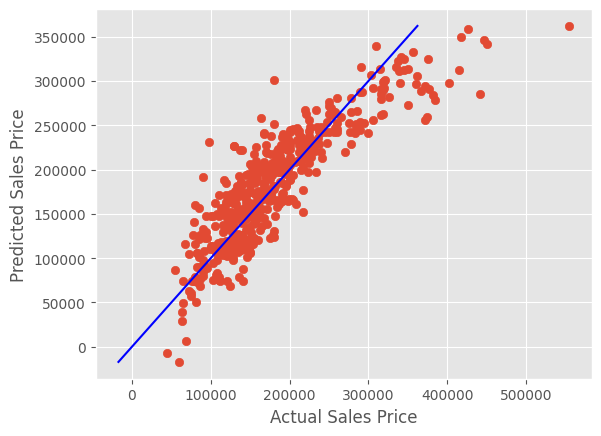

In [454]:
y2_pred = my_fit_rr2.predict(X2_test)
plt.scatter(y2_test, y2_pred)
plt.plot([min(y2_pred), max(y2_pred)],[min(y2_pred), max(y2_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next RMSPE will be calculated

In [455]:
(((y2_test - y2_pred) / y2_test) **2).mean()**(1/2) * 100

np.float64(24.560696256647354)

In [456]:
model_results2['Ridge'] = my_fit_rr2.coef_

In [457]:
model_results2

,Predictor,Linear,Ridge
0,Overall Qual,47322.064466,47104.487462
1,Gr Liv Area,28319.109156,28310.377894


The RMSE with Ridge regularization is actually higher than scaled alone.

Next Lasso regularization will be explored.

In [458]:
# Specify values of alpha we want to try
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000]

# Create empty list to hold results
results_alpha = []

for i in alpha:
  # Train the model
  my_fit_lasso2 = Lasso(alpha = i, tol = .01, max_iter=100_000) # Looping through alpha
  my_fit_lasso2.fit(X2_train, y2_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_lasso2,
      X2_scaled,
      y2,
      scoring='neg_root_mean_squared_error',
      cv = 10
  )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df2 = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df2.sort_values(by=['RMSE']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.757e+12, tolerance: 1.325e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.935e+12, tolerance: 1.461e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.851e+12, tolerance: 1.438e

           Alpha          RMSE
10  4.000000e+00  39841.302815
9   3.000000e+00  39841.303191
8   2.000000e+00  39841.303600
12  1.000000e+01  39841.303767
7   1.000000e+00  39841.303935
6   1.000000e-01  39841.304638
5   1.000000e-02  39841.304763
4   1.000000e-03  39841.304782
3   1.000000e-04  39841.304784
2   1.000000e-08  39841.304785
1   1.000000e-10  39841.304785
0   1.000000e-15  39841.304785
14  3.000000e+01  39841.325254
13  2.000000e+01  39841.327681
11  5.000000e+00  39841.504273
16  1.000000e+02  39841.546100
17  2.000000e+02  39841.791987
18  3.000000e+02  39842.359506
15  5.000000e+01  39843.349976
19  5.000000e+02  39844.459392
20  1.000000e+03  39855.335974


In [459]:
results_df2

,Alpha,RMSE
0,1.000000e-15,39841.304785
1,1.000000e-10,39841.304785
2,1.000000e-08,39841.304785
3,1.000000e-04,39841.304784
4,1.000000e-03,39841.304782
5,1.000000e-02,39841.304763
6,1.000000e-01,39841.304638
7,1.000000e+00,39841.303935
8,2.000000e+00,39841.303600
9,3.000000e+00,39841.303191


The lowest RMSE was with alpha= 4, so this value will be used for Lasso cross validation

In [460]:
my_fit_lasso2 = Lasso(alpha = 4, tol = .01, max_iter=1000000)
my_fit_lasso2.fit(X2_train, y2_train)

results = cross_val_score(my_fit_lasso2, X2_scaled, y2, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 39841.30281505683


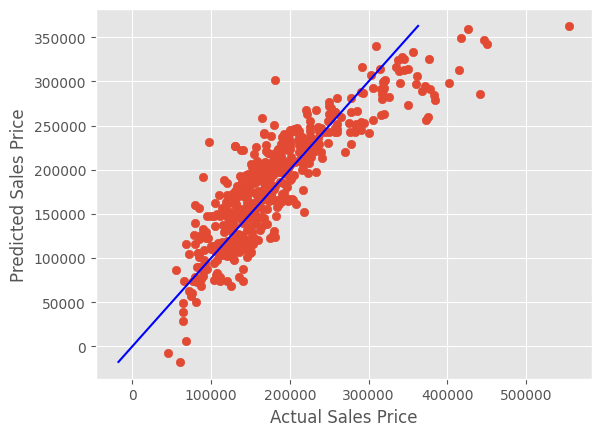

In [461]:
y2_pred = my_fit_lasso2.predict(X2_test)
plt.scatter(y2_test, y2_pred)
plt.plot([min(y2_pred), max(y2_pred)],[min(y2_pred), max(y2_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next RMSPE will be calculated

In [462]:
(((y2_test - y2_pred) / y2_test) **2).mean()**(1/2) * 100

np.float64(24.61823422794089)

In [463]:
model_results2['Lasso'] = my_fit_lasso2.coef_

In [464]:
model_results2

,Predictor,Linear,Ridge,Lasso
0,Overall Qual,47322.064466,47104.487462,47325.235143
1,Gr Liv Area,28319.109156,28310.377894,28313.441128


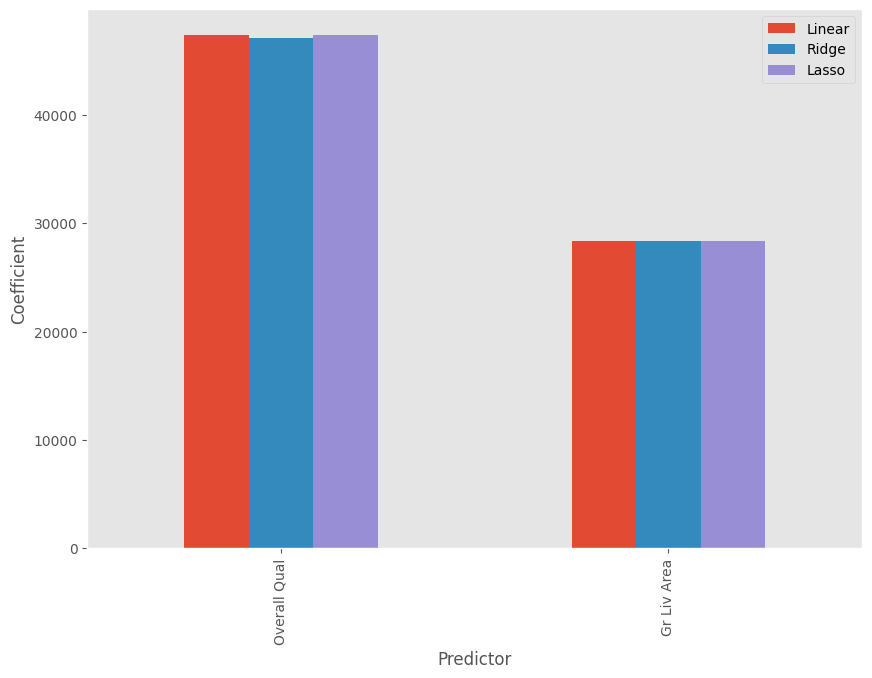

In [465]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
model_results2.plot(x = 'Predictor', kind = 'bar', ax = ax)
ax.set_ylabel('Coefficient')
plt.grid()

Both Lasso and Ridge Regularization did not make a better prediction than the regular scaled model.  Additionally, all of the RMSE with just the 2 features selected by using the |0.7| correlation was higher than with the large set created using |0.25| correlation.

Next an intermediate set selected by |0.5| correlation will be explored.

### Multiple Linear Regression with correlation cut off of |0.5|

Multiple Linear regression will be explored with and without regularization. Data will be reduced to only features that correlate with Sales Price at |0.5| or greater, which consist of Overall Qual, Year Built, Year Remodel/Addition, 1st Flr SF, Gr Liv Area, Full Bath, Kitchen Ex, and Kitchen TA.

In [466]:
X3 = housing_dfcleaned2.drop(['Lot Area', 'Central Air', '2nd Flr SF', 'Half Bath', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'NoRidge', 'NridgHt', 'StoneBr', 'Heat QC Ex', 'Heat QC TA', 'Kitchen Gd', 'Partial', 'SalePrice'], axis = 1).copy()
y3 = housing_dfcleaned2['SalePrice']

scaler = StandardScaler()
scaler.fit_transform(X3)

array([[-1.48623738, -0.24053754, -0.96622387, ..., -1.01758939, -0.27387989,  0.98233276],
       [-1.48623738, -0.14153169, -0.82274574, ...,  0.80042093, -0.27387989,  0.98233276],
       [-0.06905858, -1.1315902 , -1.63578844, ..., -1.01758939, -0.27387989, -1.01798499],
       ...,
       [ 1.34812022,  0.32049562, -0.15318117, ..., -1.01758939, -0.27387989, -1.01798499],
       [-0.06905858,  0.08948197, -0.48796346, ...,  0.80042093, -0.27387989,  0.98233276],
       [ 0.63953082,  0.91453073,  0.75551361, ...,  0.80042093, -0.27387989,  0.98233276]])

In [467]:
X3.columns

Index(['Overall Qual', 'Year Built', 'Year Remod/Add', '1st Flr SF',
       'Gr Liv Area', 'Full Bath', 'Kitchen Ex', 'Kitchen TA'],
      dtype='object')

In [468]:
X3_scaled = pd.DataFrame(scaler.fit_transform(X3), columns=X3.columns)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3_scaled, y3, test_size = 0.2, random_state=5)

In [469]:
model = LinearRegression()
my_fit_lr3 = model.fit(X3_train, y3_train)

In [470]:
model_results3 = pd.DataFrame()
model_results3['Predictor'] = X3_train.columns
model_results3['Linear'] = my_fit_lr3.coef_
model_results3.sort_values(by=['Linear'],inplace=True, ascending=False)
model_results3

,Predictor,Linear
0,Overall Qual,27525.222986
4,Gr Liv Area,25605.285994
6,Kitchen Ex,13884.486384
1,Year Built,12444.601166
3,1st Flr SF,12004.435415
2,Year Remod/Add,4851.769145
7,Kitchen TA,-3155.345352
5,Full Bath,-3999.886304


In [471]:
results3 = cross_val_score(
    model,
    X3_scaled,
    y3,
    scoring='neg_root_mean_squared_error',
    cv = 10
    )
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 39841.30281505683


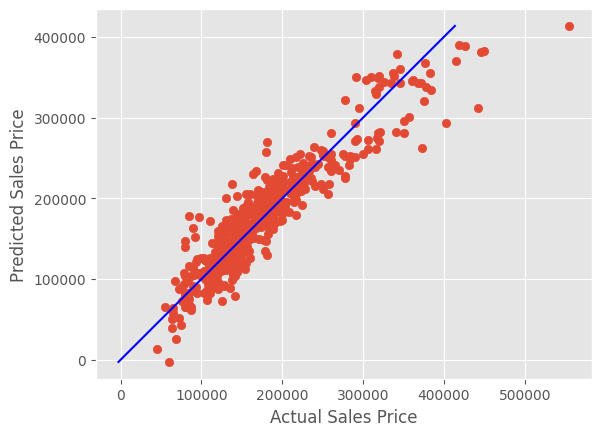

In [472]:
y3_pred = my_fit_lr3.predict(X3_test)
plt.scatter(y3_test, y3_pred)
plt.plot([min(y3_pred), max(y3_pred)],[min(y3_pred), max(y3_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next RMSPE will be calculated

In [473]:
(((y3_test - y3_pred) / y3_test) **2).mean()**(1/2) * 100

np.float64(18.58346748147977)

Next Ridge Regression will be explored

In [474]:
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000]

# Create empty list to hold results
results_alpha = []

for i in alpha:
  # Train the model
  my_fit_rr3 = Ridge(alpha = i) # Looping through alpha
  my_fit_rr3.fit(X3_train, y3_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_rr3,
      X3_scaled,
      y3,
      scoring='neg_root_mean_squared_error',
      cv = 10
      )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df3 = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df3.sort_values(by=['RMSE']))

           Alpha          RMSE
9   3.000000e+00  33125.279599
8   2.000000e+00  33125.280808
10  4.000000e+00  33125.290208
7   1.000000e+00  33125.293912
11  5.000000e+00  33125.312556
6   1.000000e-01  33125.315941
5   1.000000e-02  33125.318680
4   1.000000e-03  33125.318959
3   1.000000e-04  33125.318987
2   1.000000e-08  33125.318990
1   1.000000e-10  33125.318990
0   1.000000e-15  33125.318990
12  1.000000e+01  33125.597737
13  2.000000e+01  33127.005857
14  3.000000e+01  33129.472764
15  5.000000e+01  33137.326934
16  1.000000e+02  33171.472501
17  2.000000e+02  33285.084698
18  3.000000e+02  33437.761065
19  5.000000e+02  33806.813869
20  1.000000e+03  34877.800162


In [475]:
results_df3.sort_values( by = ["Alpha"])

,Alpha,RMSE
0,1.000000e-15,33125.318990
1,1.000000e-10,33125.318990
2,1.000000e-08,33125.318990
3,1.000000e-04,33125.318987
4,1.000000e-03,33125.318959
5,1.000000e-02,33125.318680
6,1.000000e-01,33125.315941
7,1.000000e+00,33125.293912
8,2.000000e+00,33125.280808
9,3.000000e+00,33125.279599


Alpha of 3 gives the lowest RMSE so this will be used for cross validation

In [476]:
my_fit_rr3 = Ridge(alpha = 3)
my_fit_rr3.fit(X3_train, y3_train)

# Calculate CV RMSE
results = cross_val_score(my_fit_rr3, X3_scaled, y3, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 33125.27959891601


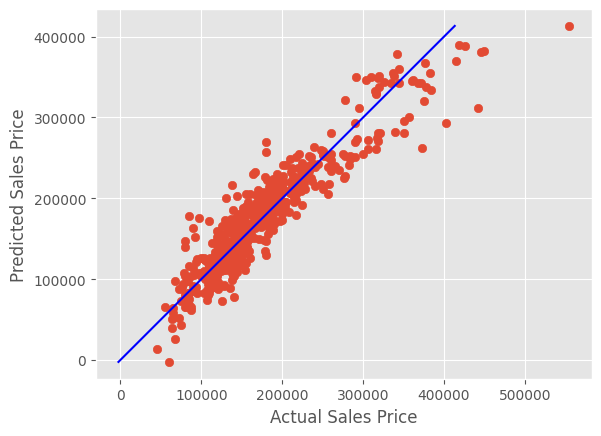

In [477]:
y3_pred = my_fit_rr3.predict(X3_test)
plt.scatter(y3_test, y3_pred)
plt.plot([min(y3_pred), max(y3_pred)],[min(y3_pred), max(y3_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next RMSPE will be calculated

In [478]:
(((y3_test - y3_pred) / y3_test) **2).mean()**(1/2) * 100

np.float64(18.5693141475711)

In [479]:
model_results3['Ridge'] = my_fit_rr3.coef_

In [480]:
model_results3

,Predictor,Linear,Ridge
0,Overall Qual,27525.222986,27478.018516
4,Gr Liv Area,25605.285994,12419.914448
6,Kitchen Ex,13884.486384,4861.420849
1,Year Built,12444.601166,12019.861230
3,1st Flr SF,12004.435415,25542.309070
2,Year Remod/Add,4851.769145,-3934.944265
7,Kitchen TA,-3155.345352,13884.237730
5,Full Bath,-3999.886304,-3175.114150


The RMSE was lower with the |0.5| coefficient set with the Ridge regression.  Next Lasso regularization will be tested.

In [481]:
# Specify values of alpha we want to try
alpha = [1e-100, 1e-30, 1e-20, 1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50, 100, 200, 300, 500, 1000]

# Create empty list to hold results
results_alpha = []

for i in alpha:
  # Train the model
  my_fit_lasso3 = Lasso(alpha = i, tol = .01, max_iter=100_000) # Looping through alpha
  my_fit_lasso3.fit(X3_train, y3_train)

  # Calculate CV RMSE
  results = cross_val_score(
      my_fit_lasso3,
      X3_scaled,
      y3,
      scoring='neg_root_mean_squared_error',
      cv = 10
  )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df3 = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df3.sort_values(by=['RMSE']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.252e+12, tolerance: 1.325e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.350e+12, tolerance: 1.461e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

            Alpha          RMSE
4    1.000000e-10  33125.318990
0   1.000000e-100  33125.318990
2    1.000000e-20  33125.318990
1    1.000000e-30  33125.318990
3    1.000000e-15  33125.318990
5    1.000000e-08  33125.318990
6    1.000000e-04  33125.318994
7    1.000000e-03  33125.319034
8    1.000000e-02  33125.319672
9    1.000000e-01  33125.322391
10   1.000000e+00  33125.367183
11   2.000000e+00  33125.380549
13   4.000000e+00  33125.390125
12   3.000000e+00  33125.543861
14   5.000000e+00  33125.568092
15   1.000000e+01  33126.026149
16   2.000000e+01  33126.029098
17   3.000000e+01  33127.429201
18   5.000000e+01  33127.884905
19   1.000000e+02  33131.449424
20   2.000000e+02  33141.817532
21   3.000000e+02  33155.414235
22   5.000000e+02  33189.624510
23   1.000000e+03  33317.940105


In [482]:
results_df3

,Alpha,RMSE
0,1.000000e-100,33125.318990
1,1.000000e-30,33125.318990
2,1.000000e-20,33125.318990
3,1.000000e-15,33125.318990
4,1.000000e-10,33125.318990
5,1.000000e-08,33125.318990
6,1.000000e-04,33125.318994
7,1.000000e-03,33125.319034
8,1.000000e-02,33125.319672
9,1.000000e-01,33125.322391


The alpha values are equally low from 1e-08 to 1e-100 in the output.  However the table sorted by RMSE suggests 1e-10 is the lowest, so this alpha value will be used for the Lasso Regularization model.

In [483]:
my_fit_lasso3 = Lasso(alpha = 1e-10, tol = .01, max_iter=1000000)
my_fit_lasso3.fit(X3_train, y3_train)

results = cross_val_score(my_fit_lasso3, X3_scaled, y3, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 33125.31898986808


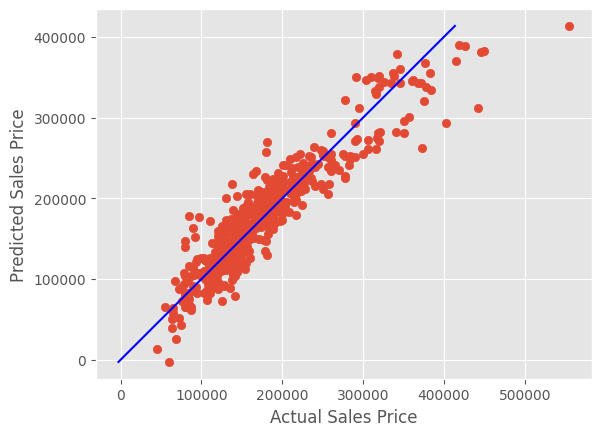

In [484]:
y3_pred = my_fit_lasso3.predict(X3_test)
plt.scatter(y3_test, y3_pred)
plt.plot([min(y3_pred), max(y3_pred)],[min(y3_pred), max(y3_pred)], c='blue')
plt.xlabel('Actual Sales Price')
plt.ylabel('Predicted Sales Price') ;

Next MSPE was calculated

In [485]:
(((y3_test - y3_pred) / y3_test) **2).mean()**(1/2) * 100

np.float64(18.583467481479765)

In [486]:
model_results3['Lasso'] = my_fit_lasso3.coef_

In [487]:
model_results3

,Predictor,Linear,Ridge,Lasso
0,Overall Qual,27525.222986,27478.018516,27525.222986
4,Gr Liv Area,25605.285994,12419.914448,12444.601166
6,Kitchen Ex,13884.486384,4861.420849,4851.769145
1,Year Built,12444.601166,12019.861230,12004.435415
3,1st Flr SF,12004.435415,25542.309070,25605.285994
2,Year Remod/Add,4851.769145,-3934.944265,-3999.886304
7,Kitchen TA,-3155.345352,13884.237730,13884.486384
5,Full Bath,-3999.886304,-3175.114150,-3155.345352


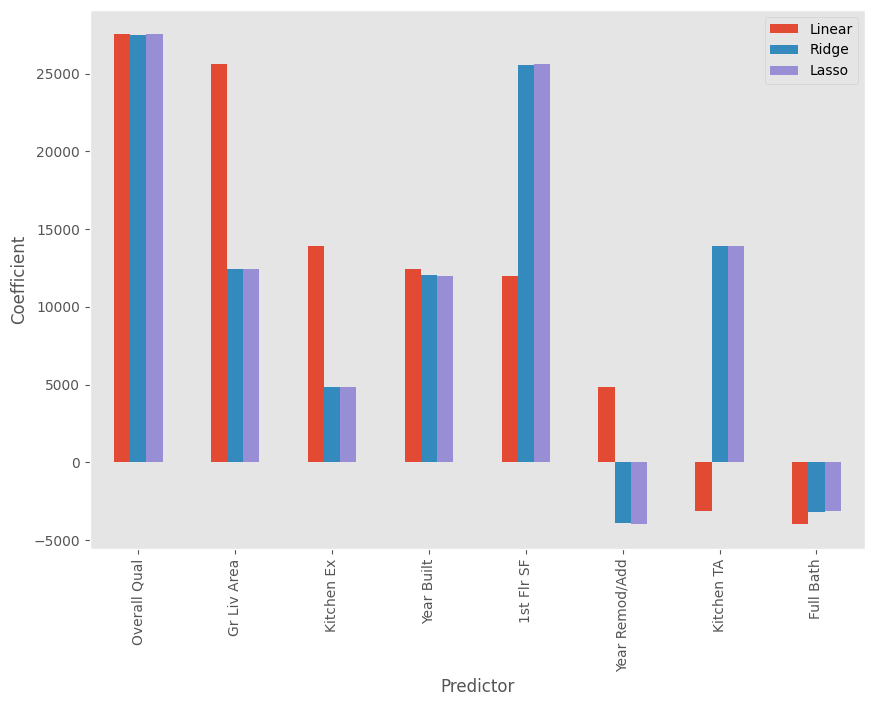

In [488]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
model_results3.plot(x = 'Predictor', kind = 'bar', ax = ax)
ax.set_ylabel('Coefficient')
plt.grid()

## Data Visualization

The largest feature set consisted of 23 features and performed the best.  Selecting for fewer features increased RMSPE.  Ridge Regularization reduced RMSPE, but Lasso did not in all cases.  

| Method | Correlation >0.25 | Correlation >0.7 | Correlation >0.5 |
|----|----|----|----|
| Linear | 16.70% | 24.62% | 18.58% |
| Ridge | 16.55% | 24.56% | 18.57% |
| Lasso | 16.69% | 24.62% | 18.58% |

The graphs of the coefficients for each model, shown in the data processing section for each feature set suggest alternative feature selections based on the coefficients could be created.




## Communicate the Results

Conclusion:

The use of more features created a more accurate model with most accurate model having a RMSPE of 16.55% with 23 features and Ridge regularization.  However, the gain between 23 features and 8 features was only ~2%.  Other feature selection, based on the coefficients from the models might optimize the features. Additionally, only standard scaling was used.  As outliers are present in some of the features, other scaling methods might be beneficial.

Future work:

Selecting other feature sets to test and alternative scaling methods might produce a more accurate model
